# Policy distillation

# 1. Inverted Double Pendulum: distilling ANN and CGP teachers

Uniform fixed-dataset cloning: four students under ANN and CGP teachers. The top row shows reward; the bottom row shows held-out MSE. Teacher distributions, splits and budgets differ.


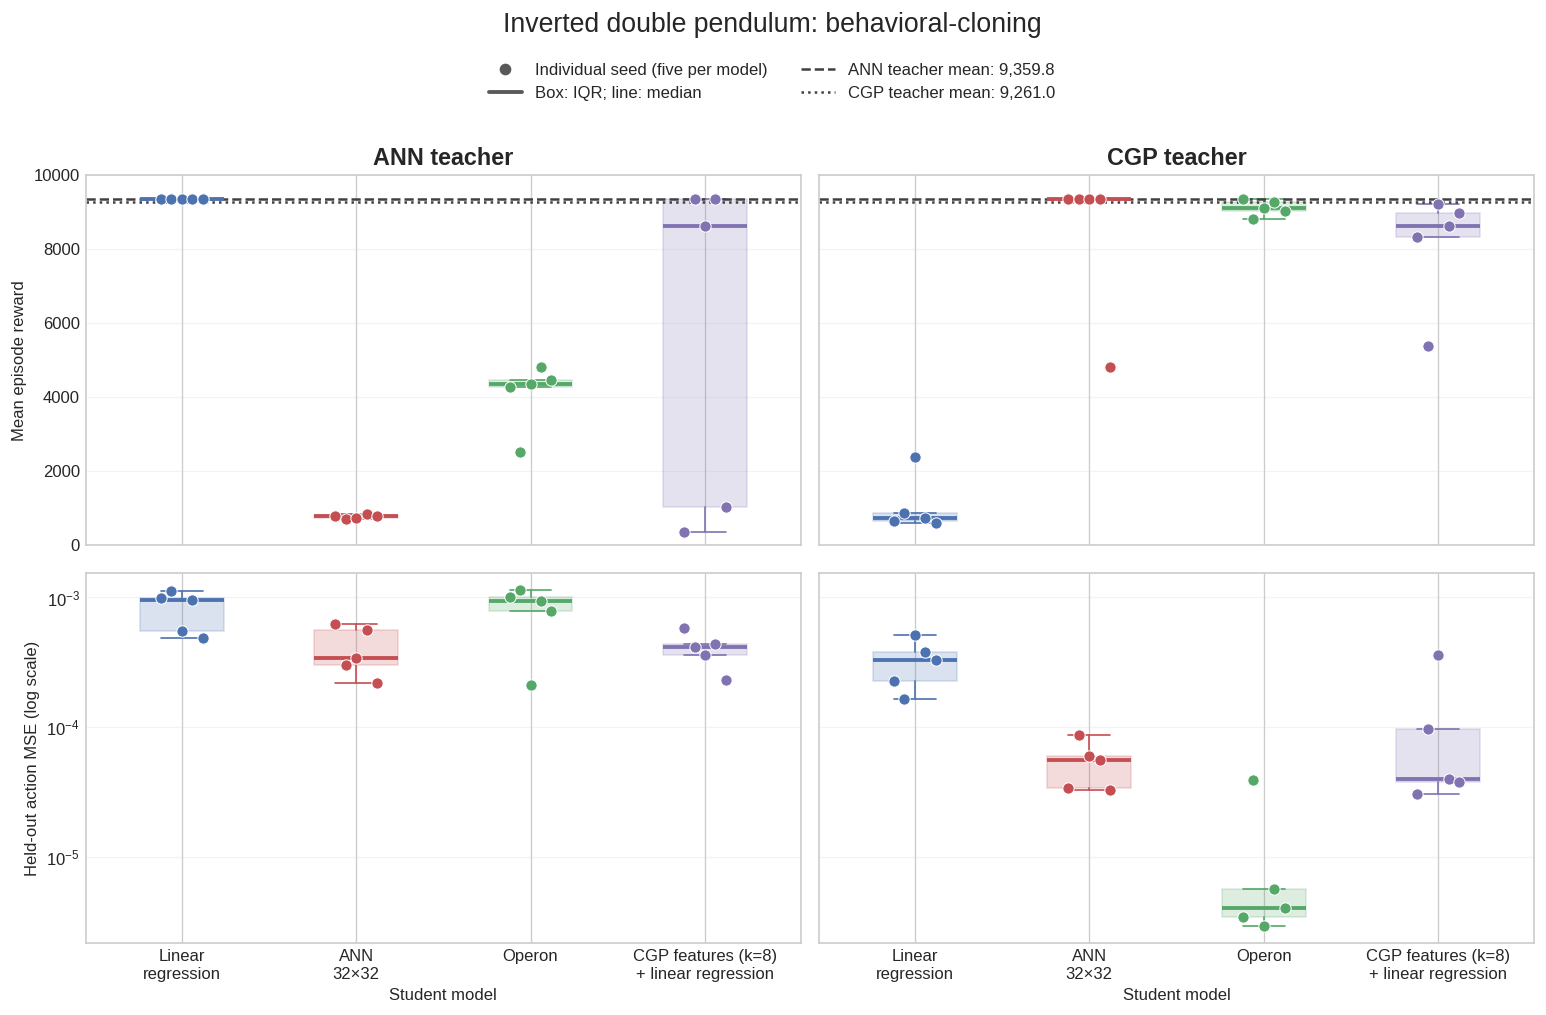

In [1]:
# Load historical baselines; the comparison below adds Inverted Pendulum and CGP features.
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
cwd = Path.cwd().resolve()
ROOT = next(path for path in (cwd, *cwd.parents) if (path / 'distillation_experiments').is_dir())
REPERTOIRES = ROOT / 'distillation_experiments' / 'artifacts' / 'repertoires'
ENVIRONMENTS = ['inverted_double_pendulum', 'hopper', 'walker2d']
ENV_LABELS = {
    'inverted_double_pendulum': 'Inverted double pendulum',
    'hopper': 'Hopper',
    'walker2d': 'Walker2d',
}
WEIGHT_LABELS = {'uniform': 'Uniform', 'q_dagger': 'Q-DAgger'}
LINEAR_INITIAL_RUNS = {
    'Uniform': 'linear_initial_uniform_5seeds_test_split',
    'Q-DAgger': 'linear_initial_qdagger_5seeds_test_split',
}
ANN_INITIAL_RUNS = {
    'inverted_double_pendulum': 'small_ann_32x32_both_5seeds',
    'hopper': 'small_ann_32x32_both_5seeds_retry',
    'walker2d': 'small_ann_32x32_both_5seeds',
}
OPERON_INITIAL_RUN = 'operon_initial_both_5seeds'

initial_rows = []
status_rows = []
for environment in ENVIRONMENTS:
    for weighting, run_name in LINEAR_INITIAL_RUNS.items():
        run_dir = REPERTOIRES / f'dagger_linear_{environment}' / run_name
        path = run_dir / 'aggregate_summary.json'
        variants = json.loads(path.read_text()).get('seeds', []) if path.exists() else []
        status_rows.append({'environment': ENV_LABELS[environment], 'model': 'Linear regression', 'weighting': weighting, 'completed': len(variants), 'requested': 5})
        for row in variants:
            initial_rows.append({
                'environment_key': environment, 'environment': ENV_LABELS[environment],
                'model': 'Linear regression', 'weighting': weighting, 'seed': row['seed'],
                'reward': row['final_reward'], 'train_mse': row['final_imitation_loss'],
                'test_mse': row['final_test_imitation_loss'],
            })
    ann_dir = REPERTOIRES / f'neural_initial_{environment}' / ANN_INITIAL_RUNS[environment]
    path = ann_dir / 'aggregate_summary.json'
    variants = json.loads(path.read_text()).get('variants', []) if path.exists() else []
    for weighting in ['Uniform', 'Q-DAgger']:
        count = sum(WEIGHT_LABELS[row['mode']] == weighting for row in variants)
        status_rows.append({'environment': ENV_LABELS[environment], 'model': '32×32 ANN', 'weighting': weighting, 'completed': count, 'requested': 5})
    for row in variants:
        initial_rows.append({
            'environment_key': environment, 'environment': ENV_LABELS[environment],
            'model': '32×32 ANN', 'weighting': WEIGHT_LABELS[row['mode']], 'seed': row['seed'],
            'reward': row['reward'], 'train_mse': row['train_loss'],
            'test_mse': row['validation_loss'],
        })
    operon_dir = REPERTOIRES / f'operon_{environment}' / OPERON_INITIAL_RUN
    path = operon_dir / 'aggregate_summary.json'
    variants = json.loads(path.read_text()).get('variants', []) if path.exists() else []
    for weighting in ['Uniform', 'Q-DAgger']:
        count = sum(WEIGHT_LABELS[row['mode']] == weighting for row in variants)
        status_rows.append({'environment': ENV_LABELS[environment], 'model': 'Operon', 'weighting': weighting, 'completed': count, 'requested': 5})
    for row in variants:
        initial_rows.append({
            'environment_key': environment, 'environment': ENV_LABELS[environment],
            'model': 'Operon', 'weighting': WEIGHT_LABELS[row['mode']], 'seed': row['seed'],
            'reward': row['reward'], 'train_mse': np.nan,
            'test_mse': row['validation_mse'],
        })

initial_results = pd.DataFrame(initial_rows)

baseline_path = REPERTOIRES / 'linear_initial_multienv_expert_baselines.json'
expert_baselines = json.loads(baseline_path.read_text())
expert_rows = [
    {'environment_key': environment, 'seed': int(seed), **payload}
    for environment, environment_payload in expert_baselines.items()
    for seed, payload in environment_payload['seeds'].items()
]
expert_by_seed = pd.DataFrame(expert_rows)

weighting_colors = {'Uniform': 'tab:blue', 'Q-DAgger': 'tab:orange'}

model_palette = {'Linear regression': '#4C72B0', '32×32 ANN': '#C44E52', 'Operon': '#55A868',
                 'CGP features + LR (k=8)': '#8172B3',
                 'Multi-CGP + LR (8 features/action)': '#DD8452'}

plot_specs = [
    ('student_reward', 'Policy reward'),
    ('imitation_loss', 'Training action MSE'),
    ('test_imitation_loss', 'Fixed expert test MSE'),
    ('dataset_size', 'Training-set size'),
]

hopper_expert_mean = expert_by_seed[expert_by_seed.environment_key == 'hopper'].mean_reward.mean()


from matplotlib.lines import Line2D

recap_cwd = Path.cwd().resolve()
recap_root = next(p for p in (recap_cwd, *recap_cwd.parents) if (p / 'distillation_experiments').is_dir())
recap_repertoires = recap_root / 'distillation_experiments/artifacts/repertoires'
recap_specs = [
    ('ANN', 'ANN', 'neural_initial_inverted_double_pendulum/small_ann_32x32_both_5seeds', 'variants', 'reward', 'validation_loss'),
    ('ANN', 'CGP features + LR', 'cgp_feature_inverted_double_pendulum/ann_teacher_bc_k8_5seeds_gpu', 'variants', 'reward', 'validation_mse'),
    ('ANN', 'Linear regression', 'dagger_linear_inverted_double_pendulum/linear_initial_uniform_5seeds_test_split', 'seeds', 'final_reward', 'final_test_imitation_loss'),
    ('ANN', 'Operon', 'operon_inverted_double_pendulum/operon_initial_both_5seeds', 'variants', 'reward', 'validation_mse'),
    ('CGP', 'ANN', 'neural_initial_inverted_double_pendulum/cgp_teacher_bc_uniform_5seeds', 'variants', 'reward', 'validation_loss'),
    ('CGP', 'CGP features + LR', 'cgp_feature_inverted_double_pendulum/cgp_teacher_bc_k8_5seeds_gpu', 'variants', 'reward', 'validation_mse'),
    ('CGP', 'Linear regression', 'dagger_linear_inverted_double_pendulum/cgp_teacher_bc_uniform_5seeds', 'seeds', 'final_reward', 'final_test_imitation_loss'),
    ('CGP', 'Operon', 'operon_inverted_double_pendulum/cgp_teacher_bc_uniform_5seeds', 'variants', 'reward', 'validation_mse'),
]
recap_rows = []
for teacher, student, directory, records_key, reward_key, mse_key in recap_specs:
    payload = json.loads((recap_repertoires / directory / 'aggregate_summary.json').read_text())
    records = [r for r in payload[records_key] if r.get('mode', 'uniform') == 'uniform']
    assert sorted(r['seed'] for r in records) == list(range(5)), (teacher, student)
    for record in records:
        recap_rows.append({'teacher': teacher, 'student': student, 'seed': record['seed'],
                           'reward': record[reward_key], 'held_out_mse': record[mse_key]})
idp_distillation_recap = pd.DataFrame(recap_rows)
assert np.isfinite(idp_distillation_recap[['reward', 'held_out_mse']].to_numpy()).all()
assert (idp_distillation_recap.held_out_mse > 0).all()

# Saved teacher means: ANN evaluation (50 episodes) and CGP dataset collection (100 episodes).
recap_teacher_means = {
    'ANN': json.loads((recap_repertoires / 'linear_initial_multienv_expert_baselines.json').read_text())['inverted_double_pendulum']['overall_mean_reward'],
    'CGP': json.loads((recap_root / 'distillation_experiments/artifacts/expert_datasets/cgp_teacher_inverted_double_pendulum.json').read_text())['mean_teacher_return'],
}
recap_teacher_styles = {'ANN': '--', 'CGP': ':'}

recap_models = ['Linear regression', 'ANN', 'Operon', 'CGP features + LR']
recap_labels = ['Linear\nregression', 'ANN\n32×32', 'Operon', 'CGP features (k=8)\n+ linear regression']
recap_colors = ['#4C72B0', '#C44E52', '#55A868', '#8172B2']
recap_fig, recap_axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True, sharey='row')
for column, teacher in enumerate(['ANN', 'CGP']):
    for row, metric in enumerate(['reward', 'held_out_mse']):
        ax = recap_axes[row, column]
        for index, (model, color) in enumerate(zip(recap_models, recap_colors)):
            values = idp_distillation_recap[
                (idp_distillation_recap.teacher == teacher)
                & (idp_distillation_recap.student == model)
            ].sort_values('seed')[metric].to_numpy()
            ax.boxplot([values], positions=[index], widths=0.48, showfliers=False,
                       patch_artist=True,
                       boxprops={'facecolor': color, 'edgecolor': color, 'alpha': 0.2},
                       medianprops={'color': color, 'linewidth': 2.3},
                       whiskerprops={'color': color}, capprops={'color': color})
            ax.scatter(index + np.linspace(-0.12, 0.12, len(values)), values,
                       color=color, s=46, edgecolor='white', linewidth=0.6, zorder=3)
        ax.set_xticks(range(4), recap_labels)
        ax.set_xlim(-0.55, 3.55)
        ax.grid(axis='y', alpha=0.22)
        if row == 0:
            ax.set_title(f'{teacher} teacher', fontsize=14, fontweight='bold')
        else:
            ax.set_xlabel('Student model')
        if metric == 'held_out_mse':
            ax.set_yscale('log')
            ax.set_ylabel('Held-out action MSE (log scale)' if column == 0 else '')
        else:
            for reference_teacher, reference_reward in recap_teacher_means.items():
                ax.axhline(reference_reward, color='0.25', linestyle=recap_teacher_styles[reference_teacher], linewidth=1.5)
            ax.set_ylim(0, 10000)
            ax.set_ylabel('Mean episode reward' if column == 0 else '')
recap_fig.suptitle('Inverted double pendulum: behavioral-cloning', fontsize=16, y=0.995)
recap_fig.legend(handles=[
    Line2D([], [], marker='o', linestyle='none', color='0.35', label='Individual seed (five per model)'),
    Line2D([], [], color='0.35', linewidth=2.3, label='Box: IQR; line: median'),
    *[Line2D([], [], color='0.25', linestyle=recap_teacher_styles[t],
             label=f'{t} teacher mean: {r:,.1f}') for t, r in recap_teacher_means.items()],
], loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=2, frameon=False)
recap_fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()


# 2. How many CGP features?

k=1,2,4,8,16,32 with ANN and CGP teachers, five seeds each. Data are matched across k within teacher/seed. Historical k=8 fitting times are unavailable.


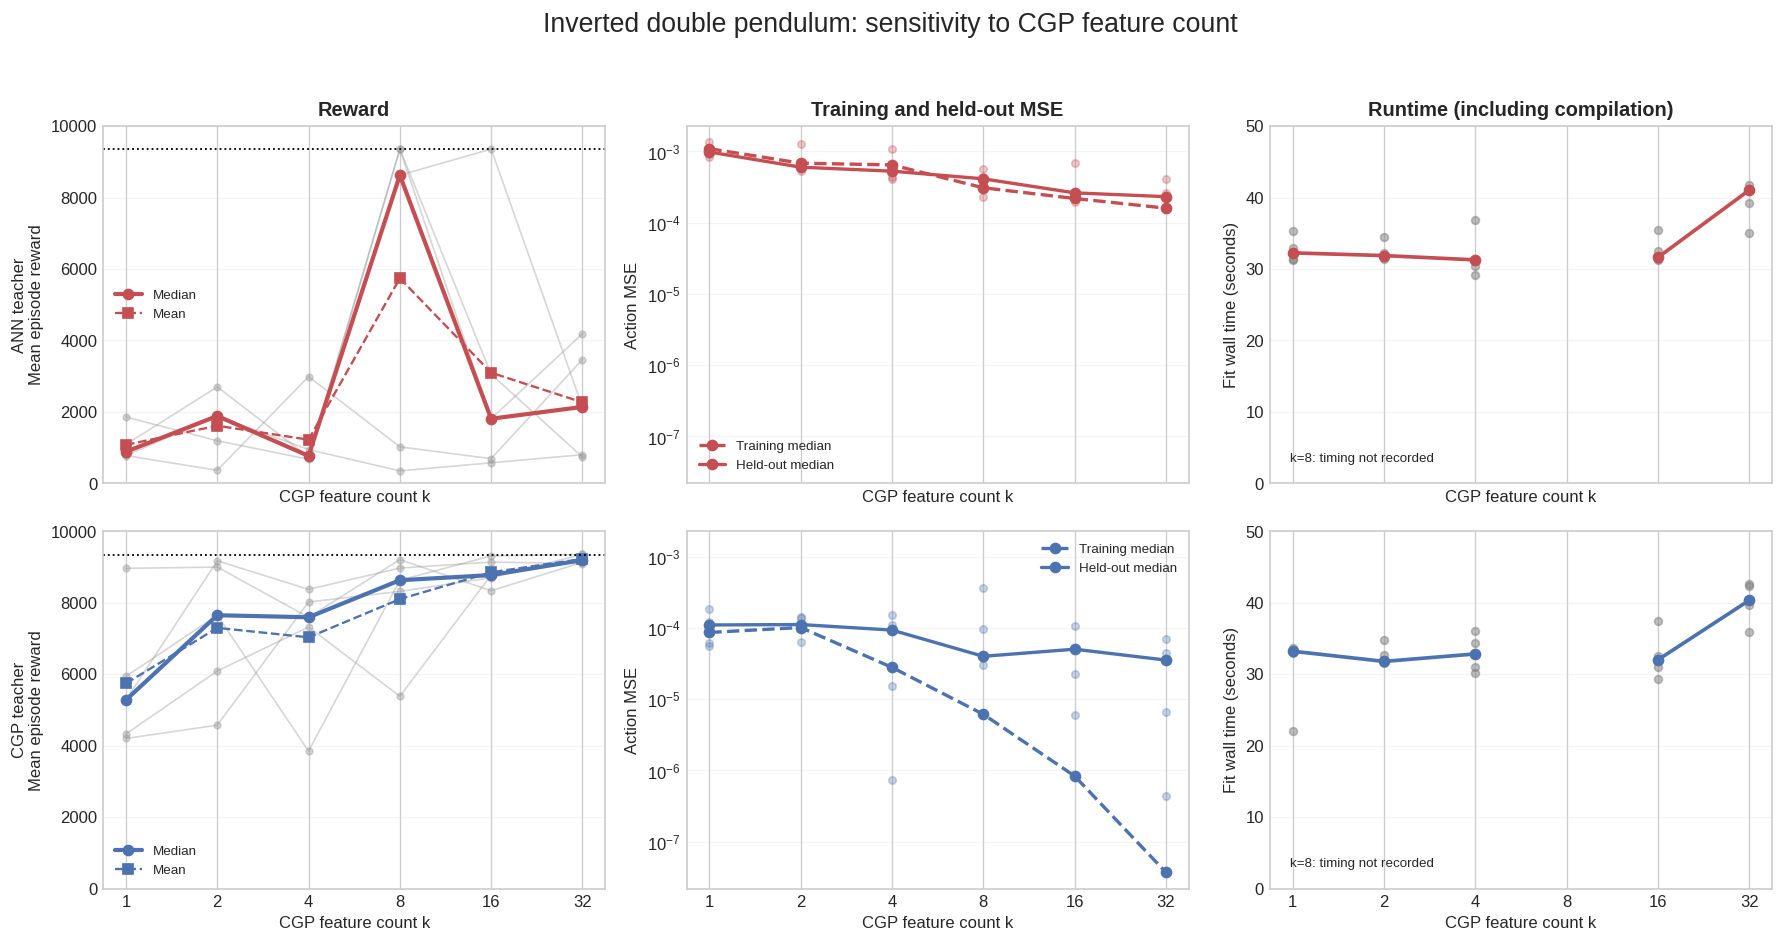

In [2]:

sensitivity_cwd = Path.cwd().resolve()
sensitivity_root = next(p for p in (sensitivity_cwd, *sensitivity_cwd.parents) if (p / 'distillation_experiments').is_dir())
sensitivity_base = sensitivity_root / 'distillation_experiments/artifacts/repertoires/cgp_feature_inverted_double_pendulum'
sensitivity_directory = sensitivity_base / 'k_sensitivity_5seeds'
sensitivity_manifest = json.loads((sensitivity_directory / 'manifest.json').read_text())
sensitivity_rows = []
sensitivity_history_rows = []
for setting in sensitivity_manifest['settings']:
    run_dir = sensitivity_base / setting['run_name']
    variants = json.loads((run_dir / 'aggregate_summary.json').read_text())['variants']
    assert sorted(record['seed'] for record in variants) == list(range(5))
    for record in variants:
        sensitivity_rows.append({
            'teacher': setting['teacher'].upper(), 'k': setting['k'], 'seed': record['seed'],
            'reward': record['reward'], 'train_mse': record['train_mse'],
            'held_out_mse': record['validation_mse'],
            'solved_9350': record['reward'] >= 9350, 'solved_9359': record['reward'] >= 9359,
            'fit_seconds': record.get('fit_seconds', np.nan),
            'evaluation_seconds': record.get('evaluation_seconds', np.nan),
            'minimum_episode_reward': min(record['trajectory_returns']),
            'reused': setting['reused'],
        })
        history = pd.read_csv(run_dir / f"seed_{record['seed']}/search_history.csv")
        assert len(history) == 100
        assert np.all(np.diff(history.best_loss.to_numpy()) <= 1e-9)
        history = history.assign(teacher=setting['teacher'].upper(), k=setting['k'], seed=record['seed'])
        sensitivity_history_rows.append(history)
sensitivity_results = pd.DataFrame(sensitivity_rows)
sensitivity_history = pd.concat(sensitivity_history_rows, ignore_index=True)
assert len(sensitivity_results) == 60
sensitivity_summary = sensitivity_results.groupby(['teacher', 'k'], sort=False).agg(
    seeds=('seed', 'count'), solved_9350=('solved_9350', 'sum'), solved_9359=('solved_9359', 'sum'),
    mean_reward=('reward', 'mean'), median_reward=('reward', 'median'),
    min_reward=('reward', 'min'), max_reward=('reward', 'max'),
    median_train_mse=('train_mse', 'median'), median_held_out_mse=('held_out_mse', 'median'),
    median_fit_seconds=('fit_seconds', 'median'), median_evaluation_seconds=('evaluation_seconds', 'median'),
).reset_index()


sensitivity_ks = [1, 2, 4, 8, 16, 32]
sensitivity_fig, sensitivity_axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey='col')
for row_index, teacher in enumerate(['ANN', 'CGP']):
    subset = sensitivity_results[sensitivity_results.teacher == teacher]
    grouped = subset.groupby('k')
    reward_ax, mse_ax, runtime_ax = sensitivity_axes[row_index]
    for seed, seed_frame in subset.groupby('seed'):
        seed_frame = seed_frame.sort_values('k')
        reward_ax.plot(seed_frame.k, seed_frame.reward, 'o-', color='0.6', alpha=0.4, linewidth=1, markersize=4)
        runtime_frame = seed_frame.dropna(subset=['fit_seconds'])
        runtime_ax.scatter(runtime_frame.k, runtime_frame.fit_seconds, color='0.5', alpha=0.5, s=22)
    color = '#4C72B0' if teacher == 'CGP' else '#C44E52'
    median_reward = grouped.reward.median().reindex(sensitivity_ks)
    reward_ax.plot(sensitivity_ks, median_reward, 'o-', color=color, linewidth=2.5, label='Median')
    reward_ax.plot(sensitivity_ks, grouped.reward.mean().reindex(sensitivity_ks), 's--', color=color, linewidth=1.4, label='Mean')
    reward_ax.axhline(9350, color='black', linestyle=':', linewidth=1.1)
    reward_ax.set(ylabel=f'{teacher} teacher\nMean episode reward', ylim=(0, 10000))
    reward_ax.legend(fontsize=8)
    for metric, style, label in [('train_mse', '--', 'Training median'), ('held_out_mse', '-', 'Held-out median')]:
        med = grouped[metric].median().reindex(sensitivity_ks)
        mse_ax.plot(sensitivity_ks, med, marker='o', linestyle=style, color=color, linewidth=2, label=label)
    for k, k_frame in grouped:
        mse_ax.scatter([k] * len(k_frame), k_frame.held_out_mse, color=color, s=20, alpha=0.3)
    mse_ax.set(yscale='log', ylabel='Action MSE')
    mse_ax.legend(fontsize=8)
    timed = subset.dropna(subset=['fit_seconds']).groupby('k').fit_seconds.median().reindex(sensitivity_ks)
    runtime_ax.plot(timed.index, timed.values, 'o-', color=color, linewidth=2.2)
    runtime_ax.set(ylabel='Fit wall time (seconds)', ylim=(0, 50))
    runtime_ax.text(0.04, 0.06, 'k=8: timing not recorded', transform=runtime_ax.transAxes, fontsize=8)
    for ax in sensitivity_axes[row_index]:
        ax.set_xscale('log', base=2)
        ax.set_xticks(sensitivity_ks, [str(k) for k in sensitivity_ks])
        ax.grid(axis='y', alpha=0.2)
        ax.set_xlabel('CGP feature count k')
for ax, title in zip(sensitivity_axes[0], ['Reward', 'Training and held-out MSE', 'Runtime (including compilation)']):
    ax.set_title(title, fontsize=12, fontweight='bold')
sensitivity_fig.suptitle('Inverted double pendulum: sensitivity to CGP feature count', fontsize=16)
sensitivity_fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()


## Beyond the fixed dataset: Inverted Double Pendulum Q-DAgger

ANN teacher to k=8 CGP features with full replay and globally normalized Q weights. Curves end when each run stops; dashed/solid MSE lines distinguish training and held-out data.

Only Q-DAgger dataset-expansion results are saved for this k=8 student. Uniform results elsewhere use a fixed dataset; no matching Uniform expansion run is available.


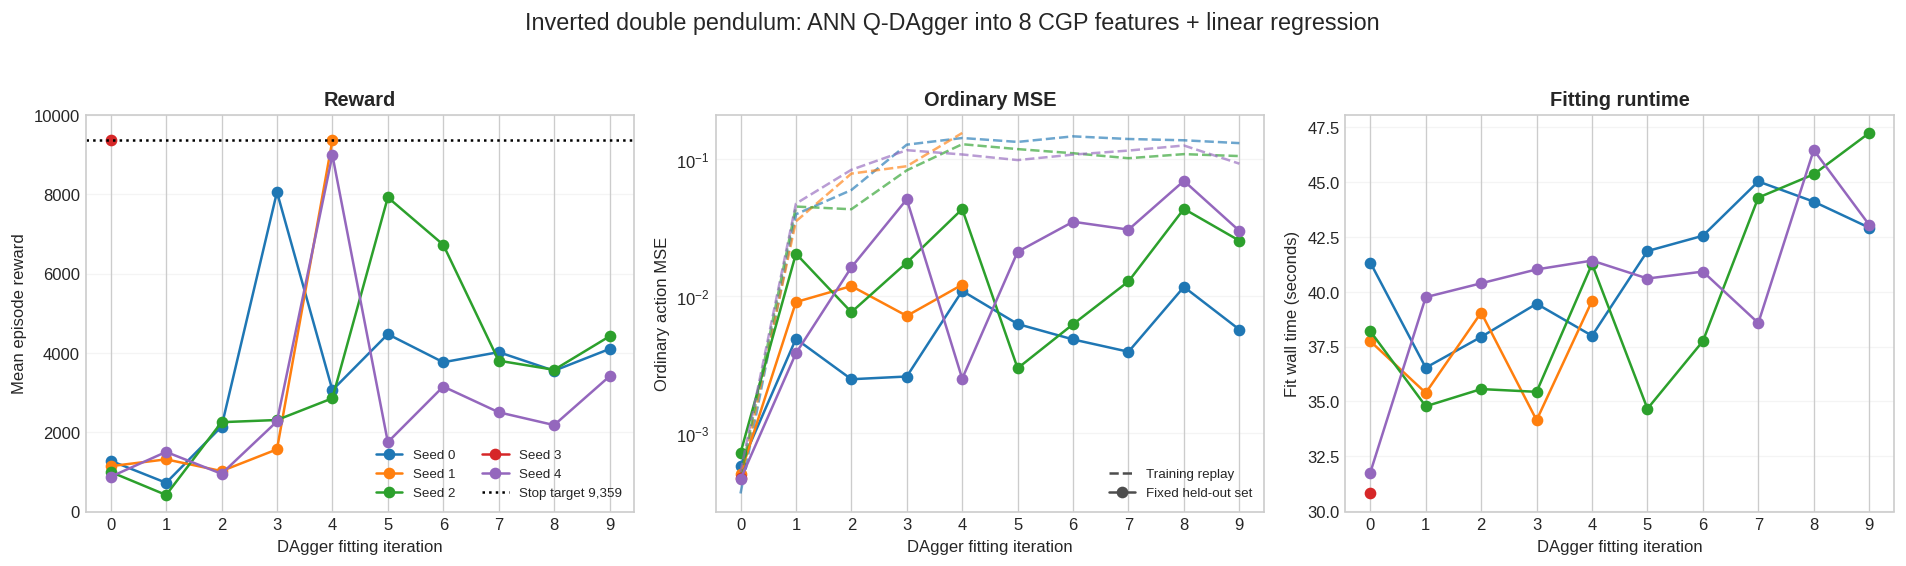

In [3]:

qf_cwd = Path.cwd().resolve()
qf_root = next(p for p in (qf_cwd, *qf_cwd.parents) if (p / 'distillation_experiments').is_dir())
qf_repertoires = qf_root / 'distillation_experiments/artifacts/repertoires'
qf_run = qf_repertoires / 'dagger_cgp_feature_inverted_double_pendulum/ann_qdagger_k8_5seeds_full_replay'
qf_summaries = pd.DataFrame(json.loads((qf_run / 'aggregate_summary.json').read_text())['variants'])
qf_history = pd.concat([
    pd.read_csv(qf_run / f'seed_{seed}/metrics.csv').assign(seed=seed)
    for seed in sorted(qf_summaries.seed)
], ignore_index=True)
qf_bc = pd.DataFrame(json.loads((qf_repertoires / 'cgp_feature_inverted_double_pendulum/ann_teacher_bc_k8_5seeds_gpu/aggregate_summary.json').read_text())['variants'])
qf_comparison = qf_summaries[['seed', 'last_iteration', 'final_reward', 'best_observed_reward', 'best_observed_iteration', 'dataset_size']].copy()
qf_comparison['uniform_BC_reward'] = qf_comparison.seed.map(qf_bc.set_index('seed').reward)
qf_comparison['Q_weighted_bootstrap_reward'] = qf_comparison.seed.map(qf_history[qf_history.iteration == 0].set_index('seed').student_reward)
qf_comparison['final_solved_9350'] = qf_comparison.final_reward >= 9350
qf_comparison['final_solved_9359'] = qf_comparison.final_reward >= 9359


qf_fig, qf_axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)
for seed, history in qf_history.groupby('seed'):
    history = history.sort_values('iteration')
    color = plt.get_cmap('tab10')(int(seed))
    qf_axes[0].plot(history.iteration, history.student_reward, 'o-', color=color, label=f'Seed {seed}')
    qf_axes[1].plot(history.iteration, history.train_mse, '--', color=color, alpha=0.65)
    qf_axes[1].plot(history.iteration, history.validation_mse, 'o-', color=color)
    qf_axes[2].plot(history.iteration, history.fit_seconds, 'o-', color=color)
qf_axes[0].axhline(9359, color='black', linestyle=':', label='Stop target 9,359')
qf_axes[0].set(ylabel='Mean episode reward', ylim=(0, 10000))
qf_axes[0].legend(fontsize=8, ncol=2)
qf_axes[1].set(ylabel='Ordinary action MSE', yscale='log')
qf_axes[1].legend(handles=[
    Line2D([], [], color='0.3', linestyle='--', label='Training replay'),
    Line2D([], [], color='0.3', marker='o', label='Fixed held-out set'),
], fontsize=8)
qf_axes[2].set_ylabel('Fit wall time (seconds)')
for ax, title in zip(qf_axes, ['Reward', 'Ordinary MSE', 'Fitting runtime']):
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.2)
    ax.set_xticks(range(10))
    ax.set_xlabel('DAgger fitting iteration')
qf_fig.suptitle('Inverted double pendulum: ANN Q-DAgger into 8 CGP features + linear regression', fontsize=14)
qf_fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


## Inverted Double Pendulum: cloning and dataset expansion

The cloning comparison is repeated with an extra ANN-teacher CGP category: each seed’s highest observed Q-DAgger reward, including iteration 0. The MSE below it comes from that same iteration, using the earliest iteration to break ties. This is a best-observed comparison selected on evaluation reward; it is not an independent final-policy evaluation. No matching CGP-teacher expansion run is available.


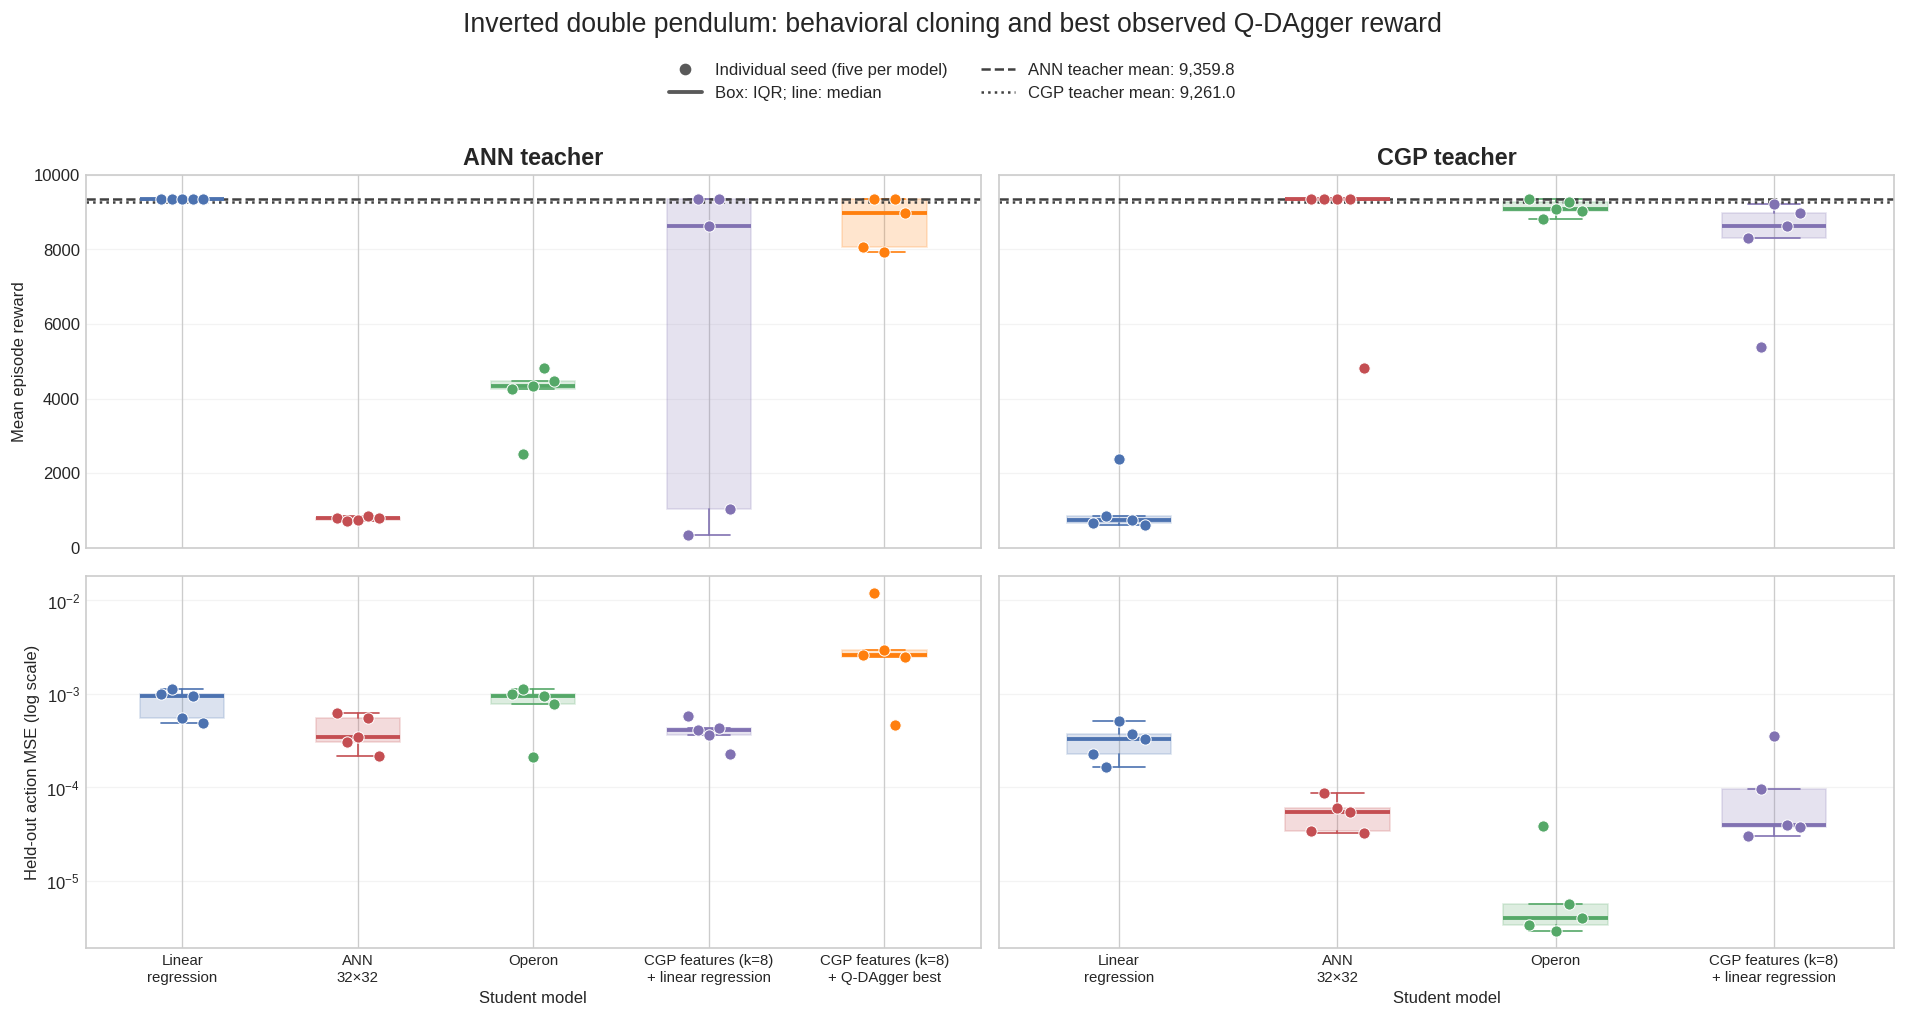

In [4]:
# Select the highest observed reward per seed; ties use the earliest iteration.
idp_expansion_best = (qf_history.sort_values(['seed', 'iteration'])
                      .loc[lambda frame: frame.groupby('seed').student_reward.idxmax()]
                      .sort_values('seed').copy())
assert idp_expansion_best.seed.tolist() == list(range(5))
assert np.allclose(idp_expansion_best.student_reward.to_numpy(),
                   qf_summaries.sort_values('seed').best_observed_reward.to_numpy())
idp_expansion_rows = pd.DataFrame({
    'teacher': 'ANN',
    'student': 'CGP features + LR (Q-DAgger best)',
    'seed': idp_expansion_best.seed.to_numpy(),
    'reward': idp_expansion_best.student_reward.to_numpy(),
    'held_out_mse': idp_expansion_best.validation_mse.to_numpy(),
})
idp_expansion_recap = pd.concat([idp_distillation_recap, idp_expansion_rows], ignore_index=True)
expansion_recap_teacher_means = recap_teacher_means
expansion_recap_teacher_styles = recap_teacher_styles

expansion_recap_models = ['Linear regression', 'ANN', 'Operon', 'CGP features + LR']
expansion_recap_labels = ['Linear\nregression', 'ANN\n32×32', 'Operon', 'CGP features (k=8)\n+ linear regression']
expansion_recap_colors = ['#4C72B0', '#C44E52', '#55A868', '#8172B2']
expansion_recap_fig, expansion_recap_axes = plt.subplots(2, 2, figsize=(16, 8.5), sharex=False, sharey='row')
for column, teacher in enumerate(['ANN', 'CGP']):
    teacher_models = expansion_recap_models + (['CGP features + LR (Q-DAgger best)'] if teacher == 'ANN' else [])
    teacher_labels = expansion_recap_labels + (['CGP features (k=8)\n+ Q-DAgger best'] if teacher == 'ANN' else [])
    teacher_colors = expansion_recap_colors + (['#ff7f0e'] if teacher == 'ANN' else [])
    for row, metric in enumerate(['reward', 'held_out_mse']):
        ax = expansion_recap_axes[row, column]
        for index, (model, color) in enumerate(zip(teacher_models, teacher_colors)):
            values = idp_expansion_recap[
                (idp_expansion_recap.teacher == teacher)
                & (idp_expansion_recap.student == model)
            ].sort_values('seed')[metric].to_numpy()
            ax.boxplot([values], positions=[index], widths=0.48, showfliers=False,
                       patch_artist=True,
                       boxprops={'facecolor': color, 'edgecolor': color, 'alpha': 0.2},
                       medianprops={'color': color, 'linewidth': 2.3},
                       whiskerprops={'color': color}, capprops={'color': color})
            ax.scatter(index + np.linspace(-0.12, 0.12, len(values)), values,
                       color=color, s=46, edgecolor='white', linewidth=0.6, zorder=3)
        ax.set_xticks(range(len(teacher_models)), teacher_labels)
        ax.tick_params(axis='x', labelbottom=(row == 1), labelsize=9)
        ax.set_xlim(-0.55, len(teacher_models) - 0.45)
        ax.grid(axis='y', alpha=0.22)
        if row == 0:
            ax.set_title(f'{teacher} teacher', fontsize=14, fontweight='bold')
        else:
            ax.set_xlabel('Student model')
        if metric == 'held_out_mse':
            ax.set_yscale('log')
            ax.set_ylabel('Held-out action MSE (log scale)' if column == 0 else '')
        else:
            for reference_teacher, reference_reward in expansion_recap_teacher_means.items():
                ax.axhline(reference_reward, color='0.25', linestyle=expansion_recap_teacher_styles[reference_teacher], linewidth=1.5)
            ax.set_ylim(0, 10000)
            ax.set_ylabel('Mean episode reward' if column == 0 else '')
expansion_recap_fig.suptitle('Inverted double pendulum: behavioral cloning and best observed Q-DAgger reward', fontsize=16, y=0.995)
expansion_recap_fig.legend(handles=[
    Line2D([], [], marker='o', linestyle='none', color='0.35', label='Individual seed (five per model)'),
    Line2D([], [], color='0.35', linewidth=2.3, label='Box: IQR; line: median'),
    *[Line2D([], [], color='0.25', linestyle=expansion_recap_teacher_styles[t],
             label=f'{t} teacher mean: {r:,.1f}') for t, r in expansion_recap_teacher_means.items()],
], loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=2, frameon=False)
expansion_recap_fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()


# 3. Scaling to more actions: replacing parts of the ANN policy first (Hopper environment)

Median rewards on a common color scale. Rows compare one versus two replaced actions; columns show linear regression, then Operon.


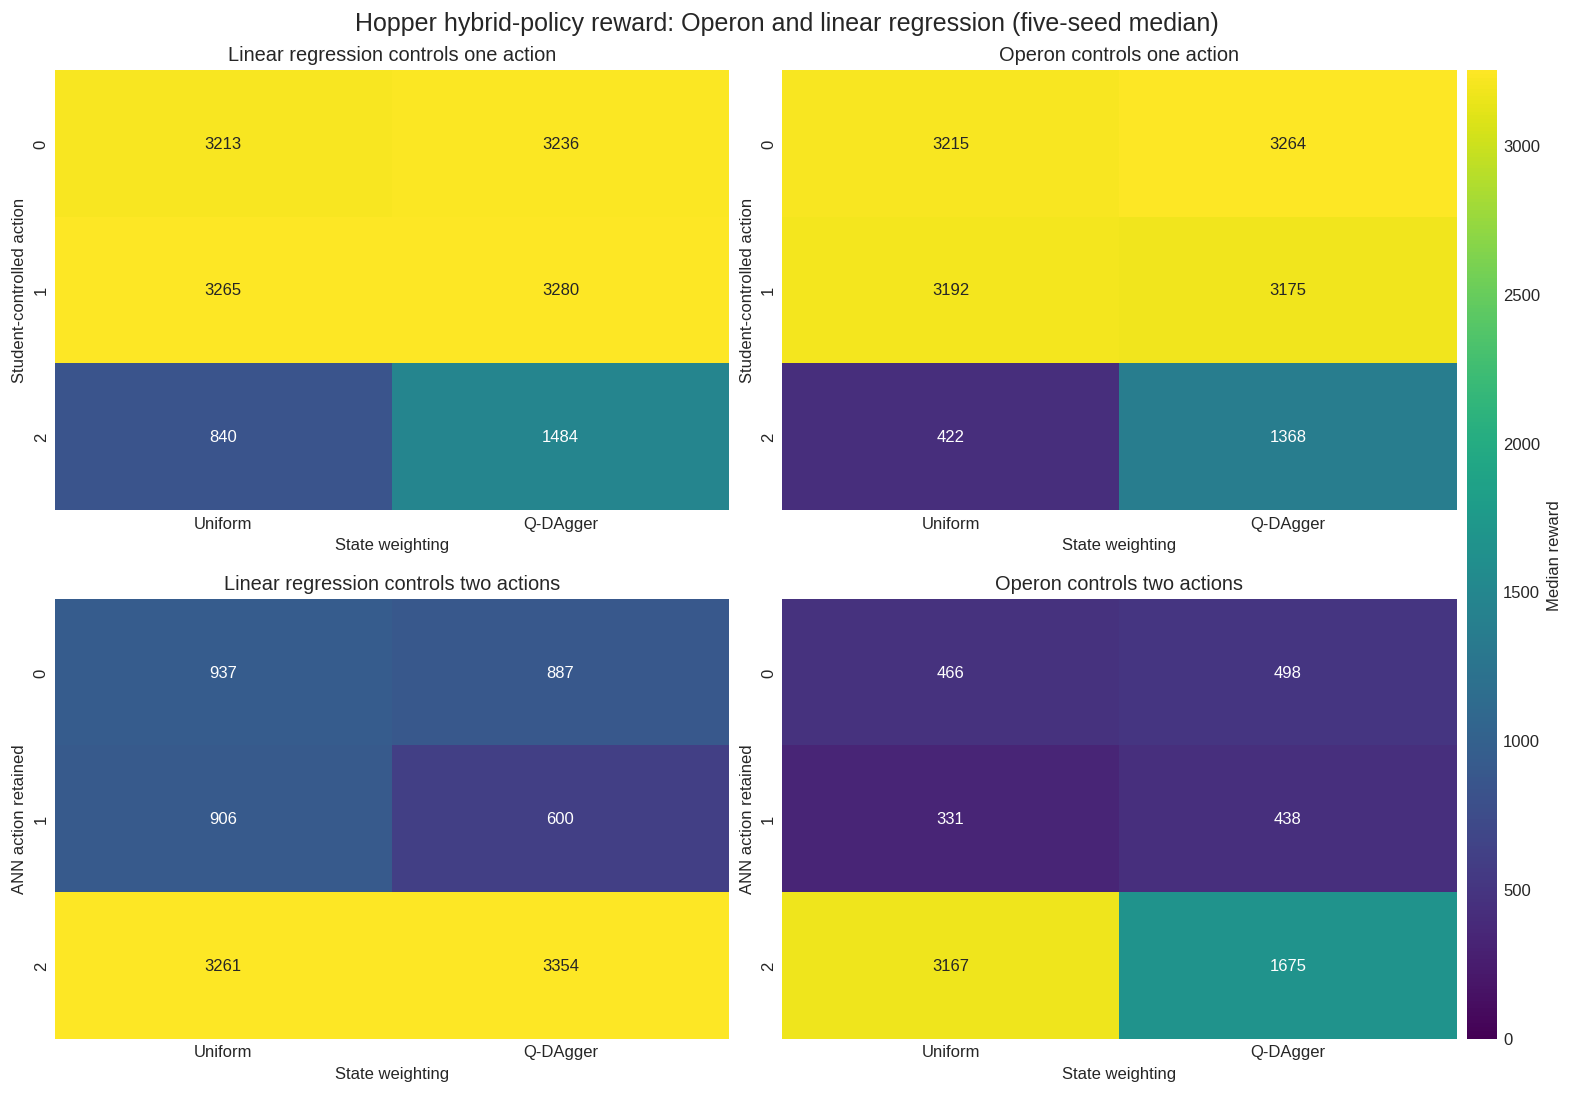

In [5]:
LINEAR_HYBRID_DIR = REPERTOIRES / 'linear_action_hybrid_hopper/linear_one_and_two_actions_both_5seeds_initial_retry'
linear_hybrid_payload = json.loads((LINEAR_HYBRID_DIR / 'aggregate_summary.json').read_text())
linear_hybrid = pd.DataFrame(linear_hybrid_payload['variants'])
linear_hybrid['weighting'] = linear_hybrid['mode'].map(WEIGHT_LABELS)
linear_hybrid['linear_count'] = linear_hybrid.linear_action_indices.map(len)
linear_hybrid['linear_actions'] = linear_hybrid.linear_action_indices.map(
    lambda indices: '+'.join(map(str, indices))
)
linear_hybrid['ann_actions'] = linear_hybrid.ann_action_indices.map(
    lambda indices: '+'.join(map(str, indices))
)

OPERON_ONE_DIR = REPERTOIRES / 'operon_single_action_hybrid_hopper/operon_one_action_both_5seeds_initial'
OPERON_TWO_DIR = REPERTOIRES / 'operon_two_action_hybrid_hopper/operon_two_actions_both_5seeds_initial'
operon_one = pd.DataFrame(json.loads((OPERON_ONE_DIR / 'aggregate_summary.json').read_text())['variants'])
operon_two = pd.DataFrame(json.loads((OPERON_TWO_DIR / 'aggregate_summary.json').read_text())['variants'])
for frame in (operon_one, operon_two):
    frame['weighting'] = frame['mode'].map(WEIGHT_LABELS)
operon_one['controlled'] = operon_one.operon_action_index.astype(str)
operon_two['retained'] = operon_two.ann_action_indices.map(lambda indices: str(indices[0]))
operon_one_matrix = operon_one.pivot_table(
    index='controlled', columns='weighting', values='reward', aggfunc='median'
).reindex(index=['0', '1', '2'], columns=['Uniform', 'Q-DAgger'])
operon_two_matrix = operon_two.pivot_table(
    index='retained', columns='weighting', values='reward', aggfunc='median'
).reindex(index=['0', '1', '2'], columns=['Uniform', 'Q-DAgger'])

linear_one_matrix = linear_hybrid[linear_hybrid.linear_count == 1].pivot_table(
    index='linear_actions', columns='weighting', values='reward', aggfunc='median'
).reindex(index=['0', '1', '2'], columns=['Uniform', 'Q-DAgger'])
linear_two_matrix = linear_hybrid[linear_hybrid.linear_count == 2].pivot_table(
    index='ann_actions', columns='weighting', values='reward', aggfunc='median'
).reindex(index=['0', '1', '2'], columns=['Uniform', 'Q-DAgger'])

panels = [
    (linear_one_matrix, 'Linear regression controls one action', 'Student-controlled action'),
    (operon_one_matrix, 'Operon controls one action', 'Student-controlled action'),
    (linear_two_matrix, 'Linear regression controls two actions', 'ANN action retained'),
    (operon_two_matrix, 'Operon controls two actions', 'ANN action retained'),
]
fig = plt.figure(figsize=(13, 9), layout='constrained')
hybrid_grid = fig.add_gridspec(2, 3, width_ratios=[1, 1, .045])
axes = np.array([[fig.add_subplot(hybrid_grid[row, col]) for col in range(2)] for row in range(2)])
hybrid_colorbar_ax = fig.add_subplot(hybrid_grid[:, 2])
for index, (ax, (matrix, title, ylabel)) in enumerate(zip(axes.flat, panels)):
    sns.heatmap(matrix, annot=True, fmt='.0f', cmap='viridis', vmin=0, vmax=3250,
                ax=ax, cbar=index == 3, cbar_ax=hybrid_colorbar_ax if index == 3 else None,
                cbar_kws={'label': 'Median reward'} if index == 3 else None)
    ax.set(title=title, xlabel='State weighting', ylabel=ylabel)
fig.suptitle('Hopper hybrid-policy reward: Operon and linear regression (five-seed median)', fontsize=15)
plt.show()



# 4. Behavioral-cloning: fixed-dataset distillation across environments

Five seeds per setting across four environments. Additional shared versus independent per-action k=8 plots are retained in the supplementary section at the end.


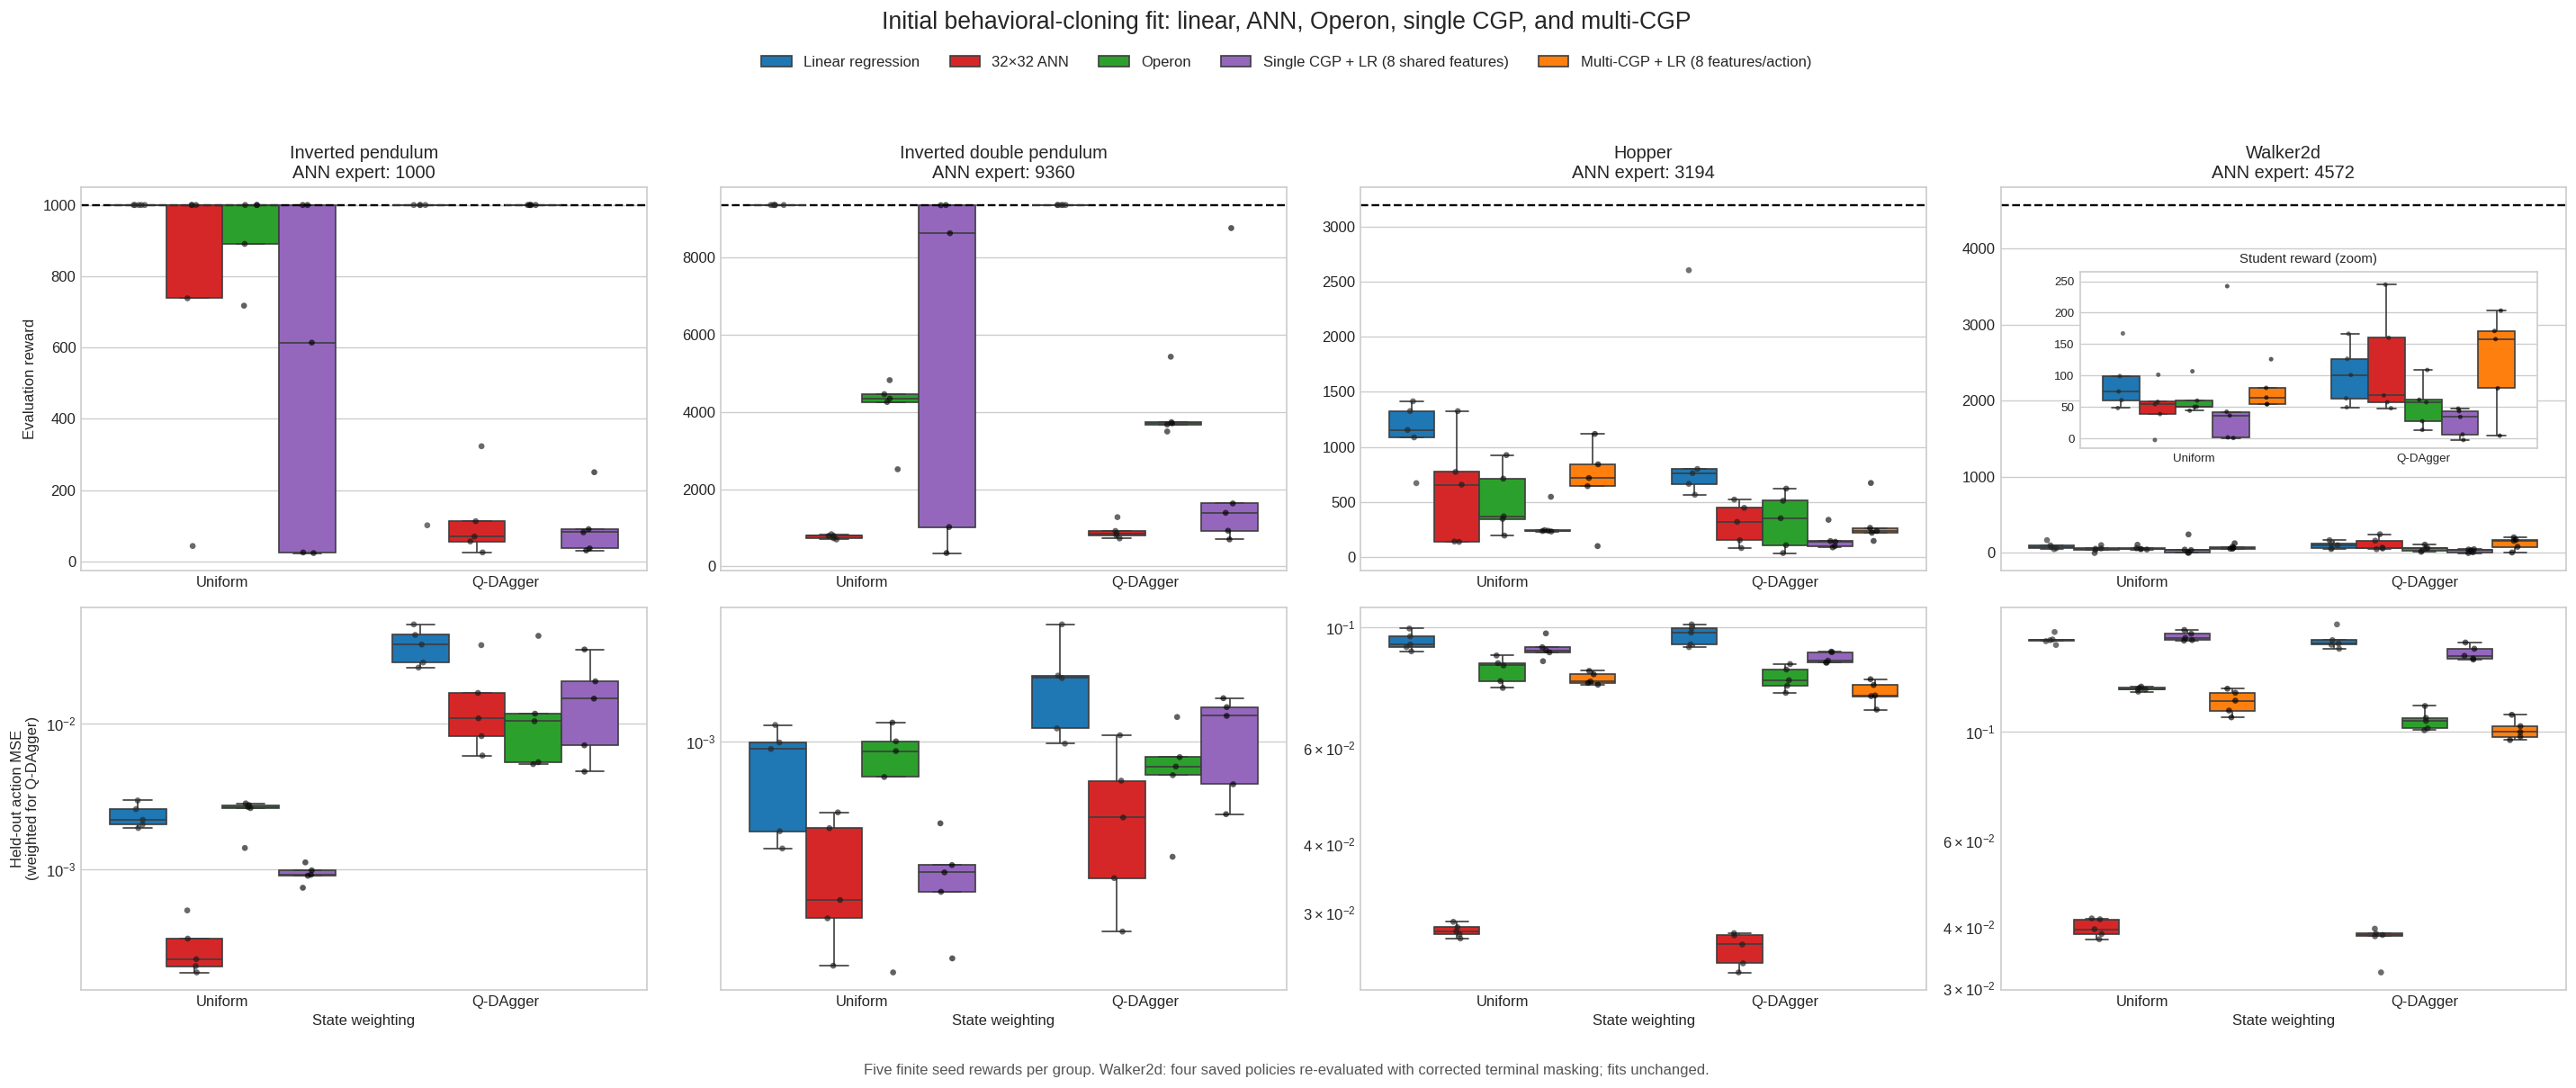

In [6]:
# Vivid, consistent student colors (Matplotlib tab10).
comparison_palette = {
    'Linear regression': '#1f77b4',
    '32×32 ANN': '#d62728',
    'Operon': '#2ca02c',
    'CGP features + LR (k=8)': '#9467bd',
    'Multi-CGP + LR (8 features/action)': '#ff7f0e',
}

# Extend the original artifact-backed comparison; no training is run here.
comparison_envs = ['inverted_pendulum', 'inverted_double_pendulum', 'hopper', 'walker2d']
comparison_labels = {'inverted_pendulum': 'Inverted pendulum', **ENV_LABELS}
comparison_rows = initial_results.to_dict('records')
comparison_sources = []
for comparison_mode, comparison_run in [
    ('uniform', 'linear_5seeds_test_split'),
    ('q_dagger', 'linear_qdagger_5seeds_test_split'),
]:
    comparison_path = REPERTOIRES / 'dagger_linear_inverted_pendulum' / comparison_run / 'aggregate_summary.json'
    comparison_variants = json.loads(comparison_path.read_text())['seeds']
    assert len(comparison_variants) == 5
    for row in comparison_variants:
        initial_metrics = pd.read_csv(comparison_path.parent / f"seed_{row['seed']}" / 'metrics.csv')
        initial_metric = initial_metrics.loc[initial_metrics.iteration.eq(0)].iloc[0]
        assert initial_metric.dataset_size == 8000
        comparison_rows.append(dict(environment_key='inverted_pendulum', environment='Inverted pendulum',
            model='Linear regression', weighting=WEIGHT_LABELS[comparison_mode], seed=row['seed'],
            reward=initial_metric.student_reward, train_mse=initial_metric.imitation_loss, test_mse=initial_metric.test_imitation_loss))
    comparison_sources.append(str(comparison_path.relative_to(ROOT)))
for comparison_model, comparison_folder, comparison_run, comparison_train, comparison_test in [
    ('32×32 ANN', 'neural_initial_inverted_pendulum', 'small_ann_32x32_both_5seeds', 'train_loss', 'validation_loss'),
    ('Operon', 'operon_inverted_pendulum', 'operon_tracked_5seeds', None, 'validation_mse'),
]:
    comparison_path = REPERTOIRES / comparison_folder / comparison_run / 'aggregate_summary.json'
    comparison_variants = json.loads(comparison_path.read_text())['variants']
    assert len(comparison_variants) == 10
    for row in comparison_variants:
        comparison_rows.append(dict(environment_key='inverted_pendulum', environment='Inverted pendulum',
            model=comparison_model, weighting=WEIGHT_LABELS[row['mode']], seed=row['seed'], reward=row['reward'],
            train_mse=row[comparison_train] if comparison_train else np.nan, test_mse=row[comparison_test]))
    comparison_sources.append(str(comparison_path.relative_to(ROOT)))
for comparison_env in comparison_envs:
    for comparison_mode in ['uniform', 'q_dagger']:
        comparison_run = ('ann_teacher_bc_k8_5seeds_gpu'
            if comparison_env == 'inverted_double_pendulum' and comparison_mode == 'uniform'
            else f'ann_initial_{comparison_mode}_k8_5seeds')
        comparison_path = REPERTOIRES / f'cgp_feature_{comparison_env}' / comparison_run / 'aggregate_summary.json'
        comparison_variants = json.loads(comparison_path.read_text())['variants']
        assert len(comparison_variants) == 5
        for row in comparison_variants:
            comparison_rows.append(dict(environment_key=comparison_env, environment=comparison_labels[comparison_env],
                model='CGP features + LR (k=8)', weighting=WEIGHT_LABELS[comparison_mode], seed=row['seed'],
                reward=row['reward'], train_mse=row.get('train_weighted_mse', row['train_mse']),
                test_mse=row['validation_weighted_mse'] if comparison_mode == 'q_dagger' else row['validation_mse']))
        comparison_sources.append(str(comparison_path.relative_to(ROOT)))
# Independent CGPs were evaluated for the two multi-action environments.
for comparison_env in ['hopper', 'walker2d']:
    for comparison_mode in ['uniform', 'q_dagger']:
        comparison_path = (REPERTOIRES / f'cgp_action_feature_{comparison_env}' /
                           f'ann_independent_{comparison_mode}_k8_5seeds' / 'aggregate_summary.json')
        comparison_variants = json.loads(comparison_path.read_text())['variants']
        assert len(comparison_variants) == 5
        for row in comparison_variants:
            comparison_rows.append(dict(environment_key=comparison_env, environment=comparison_labels[comparison_env],
                model='Multi-CGP + LR (8 features/action)', weighting=WEIGHT_LABELS[comparison_mode], seed=row['seed'],
                reward=row['reward'], train_mse=row['train_weighted_mse'],
                test_mse=row['validation_weighted_mse'] if comparison_mode == 'q_dagger' else row['validation_mse']))
        comparison_sources.append(str(comparison_path.relative_to(ROOT)))
initial_results_extended = pd.DataFrame(comparison_rows)
initial_results_extended['reward_corrected'] = False
return_corrections = json.loads((REPERTOIRES / 'initial_feature_comparison_evaluation/corrections.json').read_text())
assert len(return_corrections) == 4
for correction in return_corrections:
    correction_mask = (initial_results_extended.environment_key.eq(correction['environment_key']) & initial_results_extended.model.eq(correction['model']) & initial_results_extended.weighting.eq(correction['weighting']) & initial_results_extended.seed.eq(correction['seed']))
    assert correction_mask.sum() == 1
    initial_results_extended.loc[correction_mask, 'reward'] = correction['reward']
    initial_results_extended.loc[correction_mask, 'reward_corrected'] = True
assert not initial_results_extended.duplicated(['environment_key', 'model', 'weighting', 'seed']).any()
assert len(initial_results_extended) == 180
comparison_expert = json.loads((REPERTOIRES / 'initial_inverted_pendulum_expert_baseline.json').read_text())
comparison_expert_means = expert_by_seed.groupby('environment_key').mean_reward.mean().to_dict()
comparison_expert_means['inverted_pendulum'] = comparison_expert['inverted_pendulum']['overall_mean_reward']
comparison_order = ['Uniform', 'Q-DAgger']
comparison_models = list(comparison_palette)
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
for column, comparison_env in enumerate(comparison_envs):
    subset = initial_results_extended[initial_results_extended.environment_key == comparison_env]
    panel_models = [model for model in comparison_models if model in subset.model.values]
    for row_index, metric in enumerate(['reward', 'test_mse']):
        ax = axes[row_index, column]
        sns.boxplot(data=subset, x='weighting', y=metric, hue='model', order=comparison_order,
                    hue_order=panel_models, palette=comparison_palette, saturation=1, showfliers=False, ax=ax)
        sns.stripplot(data=subset, x='weighting', y=metric, hue='model', order=comparison_order,
                      hue_order=panel_models, dodge=True, color='black', size=4, alpha=.65,
                      legend=False, ax=ax)
        if row_index == 0:
            expert_mean = comparison_expert_means[comparison_env]
            ax.axhline(expert_mean, color='black', linestyle='--', linewidth=1.4)
            ax.set(title=f'{comparison_labels[comparison_env]}\nANN expert: {expert_mean:.0f}', xlabel='',
                   ylabel='Evaluation reward' if column == 0 else '')
        else:
            ax.set_yscale('log')
            ax.set(xlabel='State weighting', ylabel='Held-out action MSE\n(weighted for Q-DAgger)' if column == 0 else '')
        if column == 2 and row_index == 0:
            comparison_handles, comparison_legend_labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()
# Walker2d students are far below the expert; retain the expert scale and show their spread in an inset.
walker_zoom = axes[0, 3].inset_axes([.14, .32, .81, .46])
walker_subset = initial_results_extended[initial_results_extended.environment_key.eq('walker2d')]
sns.boxplot(data=walker_subset, x='weighting', y='reward', hue='model', order=comparison_order,
            hue_order=comparison_models, palette=comparison_palette, saturation=1, showfliers=False, ax=walker_zoom)
sns.stripplot(data=walker_subset, x='weighting', y='reward', hue='model', order=comparison_order,
              hue_order=comparison_models, dodge=True, color='black', size=3, alpha=.65,
              legend=False, ax=walker_zoom)
walker_zoom.set(xlabel='', ylabel='', ylim=(-15, 265))
walker_zoom.set_title('Student reward (zoom)', fontsize=9)
walker_zoom.tick_params(labelsize=8)
walker_zoom.get_legend().remove()
fig.suptitle('Initial behavioral-cloning fit: linear, ANN, Operon, single CGP, and multi-CGP', fontsize=16, y=.995)
comparison_legend_labels = ['Single CGP + LR (8 shared features)' if label == 'CGP features + LR (k=8)' else label for label in comparison_legend_labels]
fig.legend(comparison_handles, comparison_legend_labels, ncol=5, loc='upper center', bbox_to_anchor=(.5,.966))
nonfinite_count = int((~np.isfinite(initial_results_extended.reward)).sum())
coverage_note = (f'{nonfinite_count} nonfinite seed rewards; finite counts are listed in the table.' if nonfinite_count else 'Five finite seed rewards per group.')
fig.text(.5, .01, coverage_note + ' Walker2d: four saved policies re-evaluated with corrected terminal masking; fits unchanged.', ha='center', fontsize=10, color='#555555')
fig.tight_layout(rect=(0, .035, 1, .92))
plt.show()
initial_summary_extended = initial_results_extended.groupby(['environment', 'weighting', 'model']).agg(
    seeds=('seed', 'nunique'), finite_rewards=('reward', 'count'), mean_reward=('reward', 'mean'),
    std_reward=('reward', 'std'), min_reward=('reward', 'min'), max_reward=('reward', 'max'),
    mean_test_mse=('test_mse', 'mean'),
).reset_index()


# 5. Hopper: feature-count sensitivity

Five seeds per setting; Uniform and Q-DAgger weighting, shared and independent per-action CGPs. Points show seeds, lines show means, and bands show IQR. MSE is unweighted; independent policies use three times the search budget.


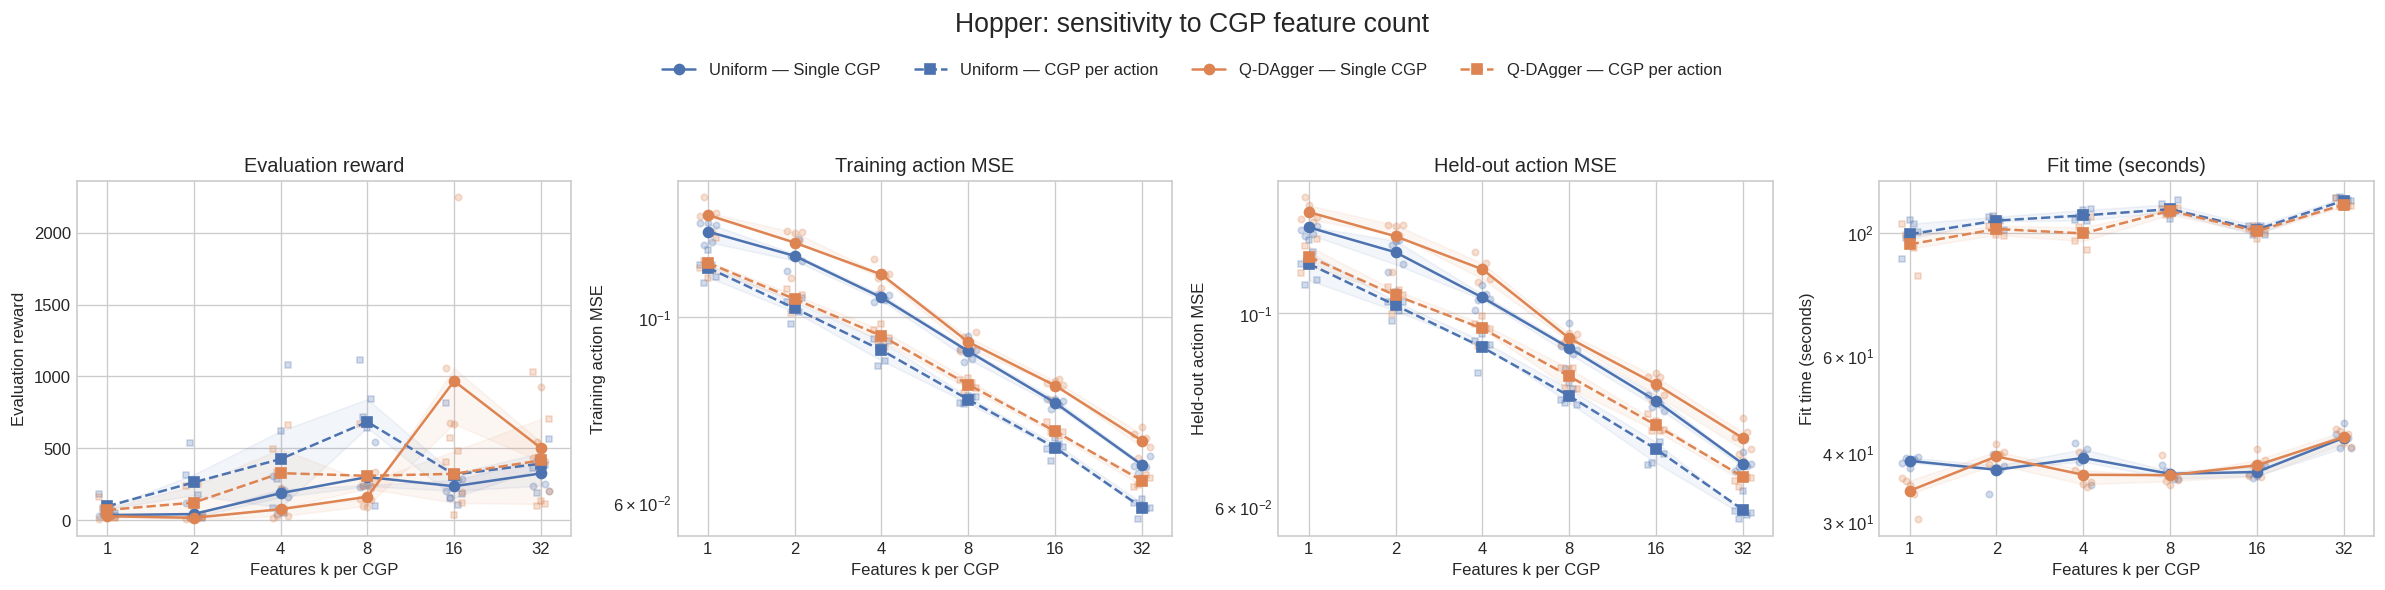

In [7]:
import sys
sweep_root = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / 'distillation_experiments').is_dir())
if str(sweep_root) not in sys.path:
    sys.path.insert(0, str(sweep_root))
from distillation_experiments.scripts.analysis.ann_feature_sensitivity_report import collect_results, summarize, plot_results
ann_sweep_results, ann_sweep_manifest = collect_results(sweep_root)
ann_sweep_summary = summarize(ann_sweep_results)
from distillation_experiments.scripts.analysis.ann_feature_sensitivity_report import COUNTS, COLORS, ARCH_STYLES, ARCH_LABELS

hopper_sweep = ann_sweep_results[ann_sweep_results.environment.eq('hopper')]
hopper_metrics = [('reward', 'Evaluation reward', False),
                  ('train_mse', 'Training action MSE', True),
                  ('held_out_mse', 'Held-out action MSE', True),
                  ('fit_seconds', 'Fit time (seconds)', True)]
hopper_sensitivity_fig, hopper_sensitivity_axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (metric, label, logarithmic) in zip(hopper_sensitivity_axes, hopper_metrics):
    for weighting in ['uniform', 'q_dagger']:
        for architecture in ['shared', 'independent']:
            values = hopper_sweep[hopper_sweep.weighting.eq(weighting) & hopper_sweep.architecture.eq(architecture)]
            color = COLORS[weighting]
            style, marker = ARCH_STYLES[architecture]
            means, lows, highs = [], [], []
            for position, k in enumerate(COUNTS):
                points = values[values.k.eq(k)][metric].to_numpy()
                points = points[np.isfinite(points)]
                if logarithmic:
                    points = points[points > 0]
                assert len(points) == 5, (weighting, architecture, k, metric)
                means.append(np.mean(points)); lows.append(np.quantile(points, .25)); highs.append(np.quantile(points, .75))
                ax.scatter(position + np.linspace(-.09, .09, len(points)), points,
                           color=color, marker=marker, s=15, alpha=.25)
            ax.plot(range(len(COUNTS)), means, color=color, linestyle=style, marker=marker,
                    label=f'{WEIGHT_LABELS[weighting]} — {ARCH_LABELS[architecture]}')
            ax.fill_between(range(len(COUNTS)), lows, highs, color=color, alpha=.07)
    ax.set(xticks=range(len(COUNTS)), xticklabels=COUNTS, xlabel='Features k per CGP', ylabel=label, title=label)
    if logarithmic:
        ax.set_yscale('log')
handles, labels = hopper_sensitivity_axes[0].get_legend_handles_labels()
hopper_sensitivity_fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(.5, .92), ncol=4, frameon=False)
hopper_sensitivity_fig.suptitle('Hopper: sensitivity to CGP feature count', fontsize=16)
hopper_sensitivity_fig.tight_layout(rect=(0, 0, 1, .84))
plt.show()


# 6. Hopper: expanding the student dataset

Median progression across five seeds. Color identifies the student model; line style identifies weighting. Training-loss conventions differ across models.

Includes shared and per-action k=16 CGP features with linear readouts. Independent CGPs use three times the search budget. Only reward, training MSE, and fixed expert-test MSE are shown.


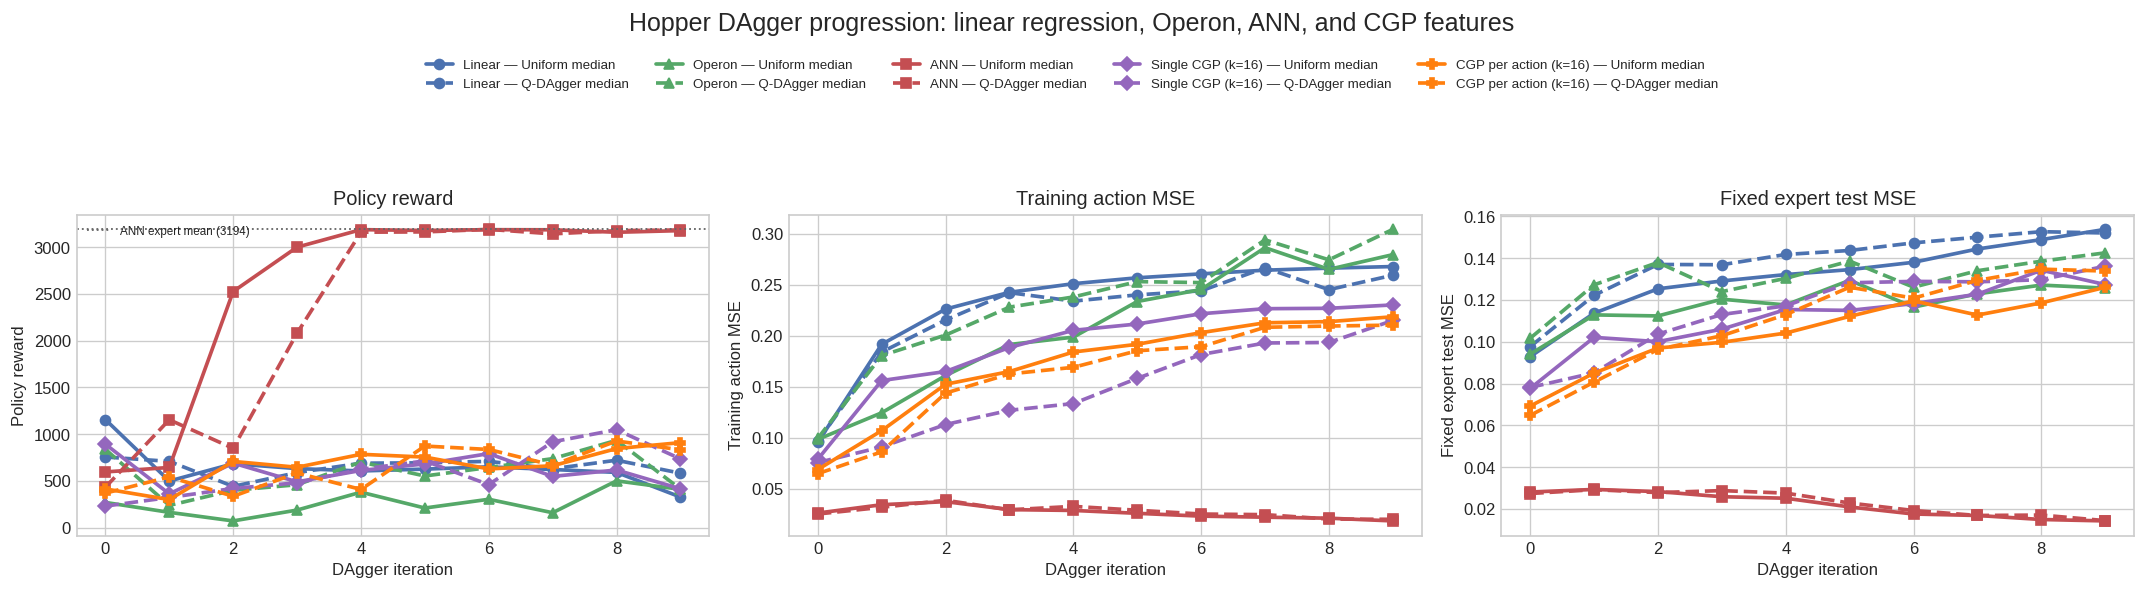

In [8]:
LINEAR_DAGGER_RUNS = {
    'Uniform': REPERTOIRES / 'dagger_linear_hopper/linear_dagger_uniform_5seeds_target3250',
    'Q-DAgger': REPERTOIRES / 'dagger_linear_hopper/linear_dagger_qdagger_5seeds_target3250',
}
linear_frames = []
for weighting, run_dir in LINEAR_DAGGER_RUNS.items():
    for path in sorted(run_dir.glob('seed_*/metrics.csv')):
        frame = pd.read_csv(path)
        frame['seed'] = int(path.parent.name.split('_')[1])
        frame['weighting'] = weighting
        frame['model'] = 'Linear regression'
        linear_frames.append(frame)
linear_history = pd.concat(linear_frames, ignore_index=True) if linear_frames else pd.DataFrame()

ANN_DAGGER_DIR = REPERTOIRES / 'dagger_neural_hopper/small_ann_32x32_dagger_both_5seeds_target3250'
ann_frames = []
ANN_COMPLETE_SEEDS = [0, 1, 2, 3, 4]
for seed in ANN_COMPLETE_SEEDS:
    for mode, weighting in WEIGHT_LABELS.items():
        path = ANN_DAGGER_DIR / f'seed_{seed}' / mode / 'metrics.csv'
        if path.exists():
            frame = pd.read_csv(path)
            frame['seed'] = seed
            frame['weighting'] = weighting
            frame['model'] = '32×32 ANN'
            ann_frames.append(frame)
ann_history = pd.concat(ann_frames, ignore_index=True) if ann_frames else pd.DataFrame()

OPERON_DAGGER_DIR = REPERTOIRES / 'dagger_operon_hopper/operon_dagger_both_5seeds_target3250'
operon_frames = []
for seed in range(5):
    for mode, weighting in WEIGHT_LABELS.items():
        variant_dir = OPERON_DAGGER_DIR / f'seed_{seed}' / mode
        metrics_path = variant_dir / 'metrics.csv'
        if not metrics_path.exists():
            continue
        frame = pd.read_csv(metrics_path)
        training_losses = {}
        for iteration in frame.iteration.astype(int):
            iteration_dir = variant_dir / f'iteration_{iteration}'
            summary_path = iteration_dir / 'summary.json'
            candidates_path = iteration_dir / 'candidates.csv'
            if not summary_path.exists() or not candidates_path.exists():
                continue
            iteration_summary = json.loads(summary_path.read_text())
            candidates = pd.read_csv(candidates_path)
            selected_losses = []
            for action_index, position in enumerate(iteration_summary['selected_positions']):
                selected = candidates[(candidates.action_index == action_index) & (candidates.position == position)]
                selected_losses.append(float(selected.iloc[0].operon_mse))
            training_losses[iteration] = float(np.mean(selected_losses))
        frame['imitation_loss'] = frame.iteration.map(training_losses)
        frame['test_imitation_loss'] = frame['validation_mse']
        frame['seed'] = seed
        frame['weighting'] = weighting
        frame['model'] = 'Operon'
        operon_frames.append(frame)
operon_history = pd.concat(operon_frames, ignore_index=True) if operon_frames else pd.DataFrame()

from distillation_experiments.scripts.analysis.hopper_feature_dagger_report import collect
cgp_dagger_history, cgp_dagger_summaries = collect()
cgp_dagger_history['weighting'] = cgp_dagger_history['mode'].map(WEIGHT_LABELS)
shared_cgp_history = cgp_dagger_history[cgp_dagger_history.architecture.eq('shared')]
independent_cgp_history = cgp_dagger_history[cgp_dagger_history.architecture.eq('independent')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_colors = {'Linear regression': '#4C72B0', '32×32 ANN': '#C44E52', 'Operon': '#55A868', 'Single CGP': '#9467bd', 'CGP per action': '#ff7f0e'}
weighting_styles = {'Uniform': '-', 'Q-DAgger': '--'}
progression_specs = [
    ('student_reward', 'Policy reward'),
    ('imitation_loss', 'Training action MSE'),
    ('test_imitation_loss', 'Fixed expert test MSE'),
]
for ax, (metric, title) in zip(axes, progression_specs):
    for model, history, marker, label in [
        ('Linear regression', linear_history, 'o', 'Linear'),
        ('Operon', operon_history, '^', 'Operon'),
        ('32×32 ANN', ann_history, 's', 'ANN'),
        ('Single CGP', shared_cgp_history, 'D', 'Single CGP (k=16)'),
        ('CGP per action', independent_cgp_history, 'P', 'CGP per action (k=16)'),
    ]:
        for weighting in ['Uniform', 'Q-DAgger']:
            subset = history[history.weighting == weighting]
            if subset.empty:
                continue
            median = subset.groupby('iteration')[metric].median()
            ax.plot(median.index, median.values, color=model_colors[model],
                    linestyle=weighting_styles[weighting], marker=marker,
                    linewidth=2.2, label=f'{label} — {weighting} median')
    if metric == 'student_reward':
        ax.axhline(hopper_expert_mean, color='0.4', linestyle=':', linewidth=1.1,
                   label=f'ANN expert mean ({hopper_expert_mean:.0f})')
    ax.set(title=title, xlabel='DAgger iteration', ylabel=title)
progression_handles, progression_labels = axes[0].get_legend_handles_labels()
axes[0].legend(progression_handles[-1:], progression_labels[-1:], fontsize=7, loc="upper left")
fig.legend(progression_handles[:-1], progression_labels[:-1], loc='upper center', bbox_to_anchor=(.5, .92), ncol=5, fontsize=8, frameon=False)
fig.suptitle('Hopper DAgger progression: linear regression, Operon, ANN, and CGP features', fontsize=15)
fig.tight_layout(rect=(0, 0, 1, .78))
plt.show()


# 7. Hopper recap: best observed reward per seed

Each point is a seed’s maximum recorded reward, including the initial iteration. DAgger uses the best 10-episode evaluation mean across iterations; direct evolution uses the best 5-episode search fitness across generations. Ties use the earliest iteration or generation. These are observed maxima with different evaluation and search budgets, not independent final-policy evaluations. All 50 DAgger runs and five direct-evolution runs are checked against their histories.

The purple dotted line in every panel shows the median of the five direct-CGP runs’ peak search fitness values.


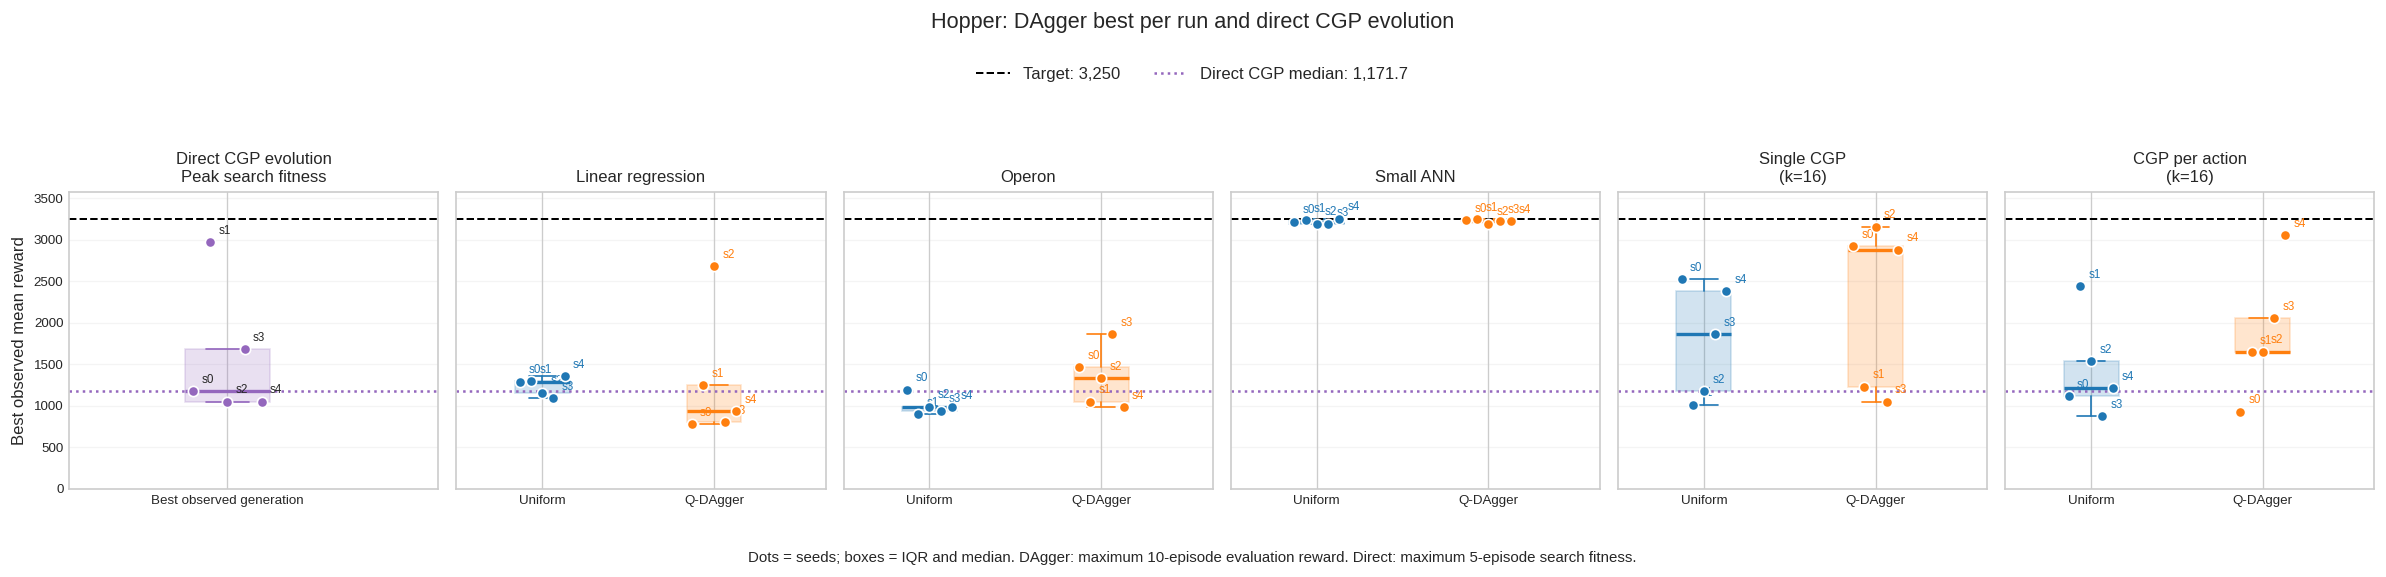

In [9]:
from distillation_experiments.scripts.analysis.hopper_feature_dagger_report import best_per_run
from distillation_experiments.scripts.analysis.hopper_best_iteration_report import collect_best_iterations

best_history, _ = collect()
hopper_peak_audit = collect_best_iterations()
assert len(hopper_peak_audit) == 50
for row in hopper_peak_audit.itertuples():
    history = pd.read_csv(REPERTOIRES / row.source).sort_values('iteration')
    assert np.isclose(row.best_reward, history.student_reward.max())
    assert row.best_iteration == int(history.loc[history.student_reward.idxmax(), 'iteration'])
direct_peak_rows = []
for seed in range(5):
    directory = REPERTOIRES.parent / 'policy_search/baselines/hopper_generalized_5seeds/hopper' / f'seed_{seed}'
    history = pd.read_csv(directory / 'metrics.csv').sort_values('generation')
    best = history.loc[history.max_fitness.idxmax()]
    summary = json.loads((directory / 'summary.json').read_text())
    assert np.isclose(best.max_fitness, summary['best_fitness'])
    direct_peak_rows.append({'seed': seed, 'reward': float(best.max_fitness), 'generation': int(best.generation)})
direct_peak_rewards = pd.DataFrame(direct_peak_rows)

def plot_best_observed_per_run(history):
    from distillation_experiments.scripts.analysis.hopper_best_iteration_report import MODELS
    all_best = collect_best_iterations()
    cgp_best = best_per_run(history)
    cgp_best['model'] = cgp_best.architecture.map({'shared': 'Single CGP (k=16)', 'independent': 'CGP per action (k=16)'})
    best = pd.concat([all_best[~all_best.model.isin(MODELS[-2:])], cgp_best], ignore_index=True)
    direct = direct_peak_rewards
    direct_reference = float(direct.reward.median())
    fig, grid = plt.subplots(1, 6, figsize=(20, 4.8), sharey=True)
    axes = grid.ravel()
    model_order = ['Linear regression', 'Operon', 'Small ANN', 'Single CGP (k=16)', 'CGP per action (k=16)']
    for ax, title in zip(axes[1:], model_order):
        for position, (mode, color) in enumerate((('uniform', 'tab:blue'), ('q_dagger', 'tab:orange'))):
            values = best[(best.model == title) & (best['mode'] == mode)].sort_values('seed')
            if values.empty:
                continue
            ax.boxplot([values.best_reward.to_numpy()], positions=[position], widths=.32,
                       patch_artist=True, showfliers=False,
                       boxprops=dict(facecolor=color, edgecolor=color, alpha=.2),
                       medianprops=dict(color=color, linewidth=2),
                       whiskerprops=dict(color=color), capprops=dict(color=color))
            for i, row in enumerate(values.itertuples()):
                x = position + (i - (len(values) - 1) / 2) * .065
                ax.scatter(x, row.best_reward, color=color, edgecolors='white', s=38, zorder=3)
                ax.annotate(f's{row.seed}', (x, row.best_reward), xytext=(5, 5),
                            textcoords='offset points', fontsize=7, color=color)
        ax.axhline(3250, color='black', linestyle='--', linewidth=1.2, label='Target: 3,250')
        ax.set(title=title.replace(' (k=16)', '\n(k=16)'), xticks=[0, 1], xticklabels=['Uniform', 'Q-DAgger'], xlim=(-.5, 1.65),
               ylim=(0, max(3500, float(best.best_reward.max()) * 1.1)))
        ax.grid(axis='y', alpha=.2)
    ax = axes[0]
    color = 'tab:purple'
    if not direct.empty:
        ax.boxplot([direct.reward.to_numpy()], positions=[0], widths=.32, patch_artist=True,
                   showfliers=False, boxprops=dict(facecolor=color, edgecolor=color, alpha=.2),
                   medianprops=dict(color=color, linewidth=2), whiskerprops=dict(color=color),
                   capprops=dict(color=color))
        for i, row in enumerate(direct.itertuples()):
            x = (i - (len(direct) - 1) / 2) * .065
            ax.scatter(x, row.reward, color=color, edgecolors='white', s=38, zorder=3)
            ax.annotate(f's{row.seed}', (x, row.reward), xytext=(5, 5), textcoords='offset points', fontsize=7)
    ax.axhline(3250, color='black', linestyle='--', linewidth=1.2)
    ax.set(title=f'Direct CGP evolution\nPeak search fitness', xticks=[0],
           xticklabels=['Best observed generation'], xlim=(-.6, .8))
    ax.grid(axis='y', alpha=.2)
    axes[0].set_ylim(0, max(3500, float(best.best_reward.max()) * 1.1,
                           0 if direct.empty else float(direct.reward.max()) * 1.1))
    for ax in axes[:1]:
        ax.set_ylabel('Best observed mean reward')
    for ax in axes:
        ax.axhline(direct_reference, color='tab:purple', linestyle=':', linewidth=1.5,
                   label=f'Direct CGP median: {direct_reference:,.1f}')
        ax.tick_params(labelsize=8)
        ax.title.set_fontsize(10)
    fig.suptitle('Hopper: DAgger best per run and direct CGP evolution', fontsize=13)
    fig.legend(*axes[1].get_legend_handles_labels(), loc='upper center', bbox_to_anchor=(.5, .91),
               ncol=2, frameon=False)
    fig.text(.5, .025, 'Dots = seeds; boxes = IQR and median. DAgger: maximum 10-episode evaluation reward. Direct: maximum 5-episode search fitness.',
             ha='center', fontsize=9)
    fig.tight_layout(rect=(0, .09, 1, .84))
    return fig

best_figure = plot_best_observed_per_run(best_history)
display(best_figure)
plt.close(best_figure)



# Supplementary: independent CGP per action, k=8

Shared versus per-action CGPs in Hopper and Walker2d, under both weightings. Each action has its own eight-feature CGP and fitted linear regression with an intercept. MSE is ordinary held-out MSE; independent graphs use 3×/6× the search budget.


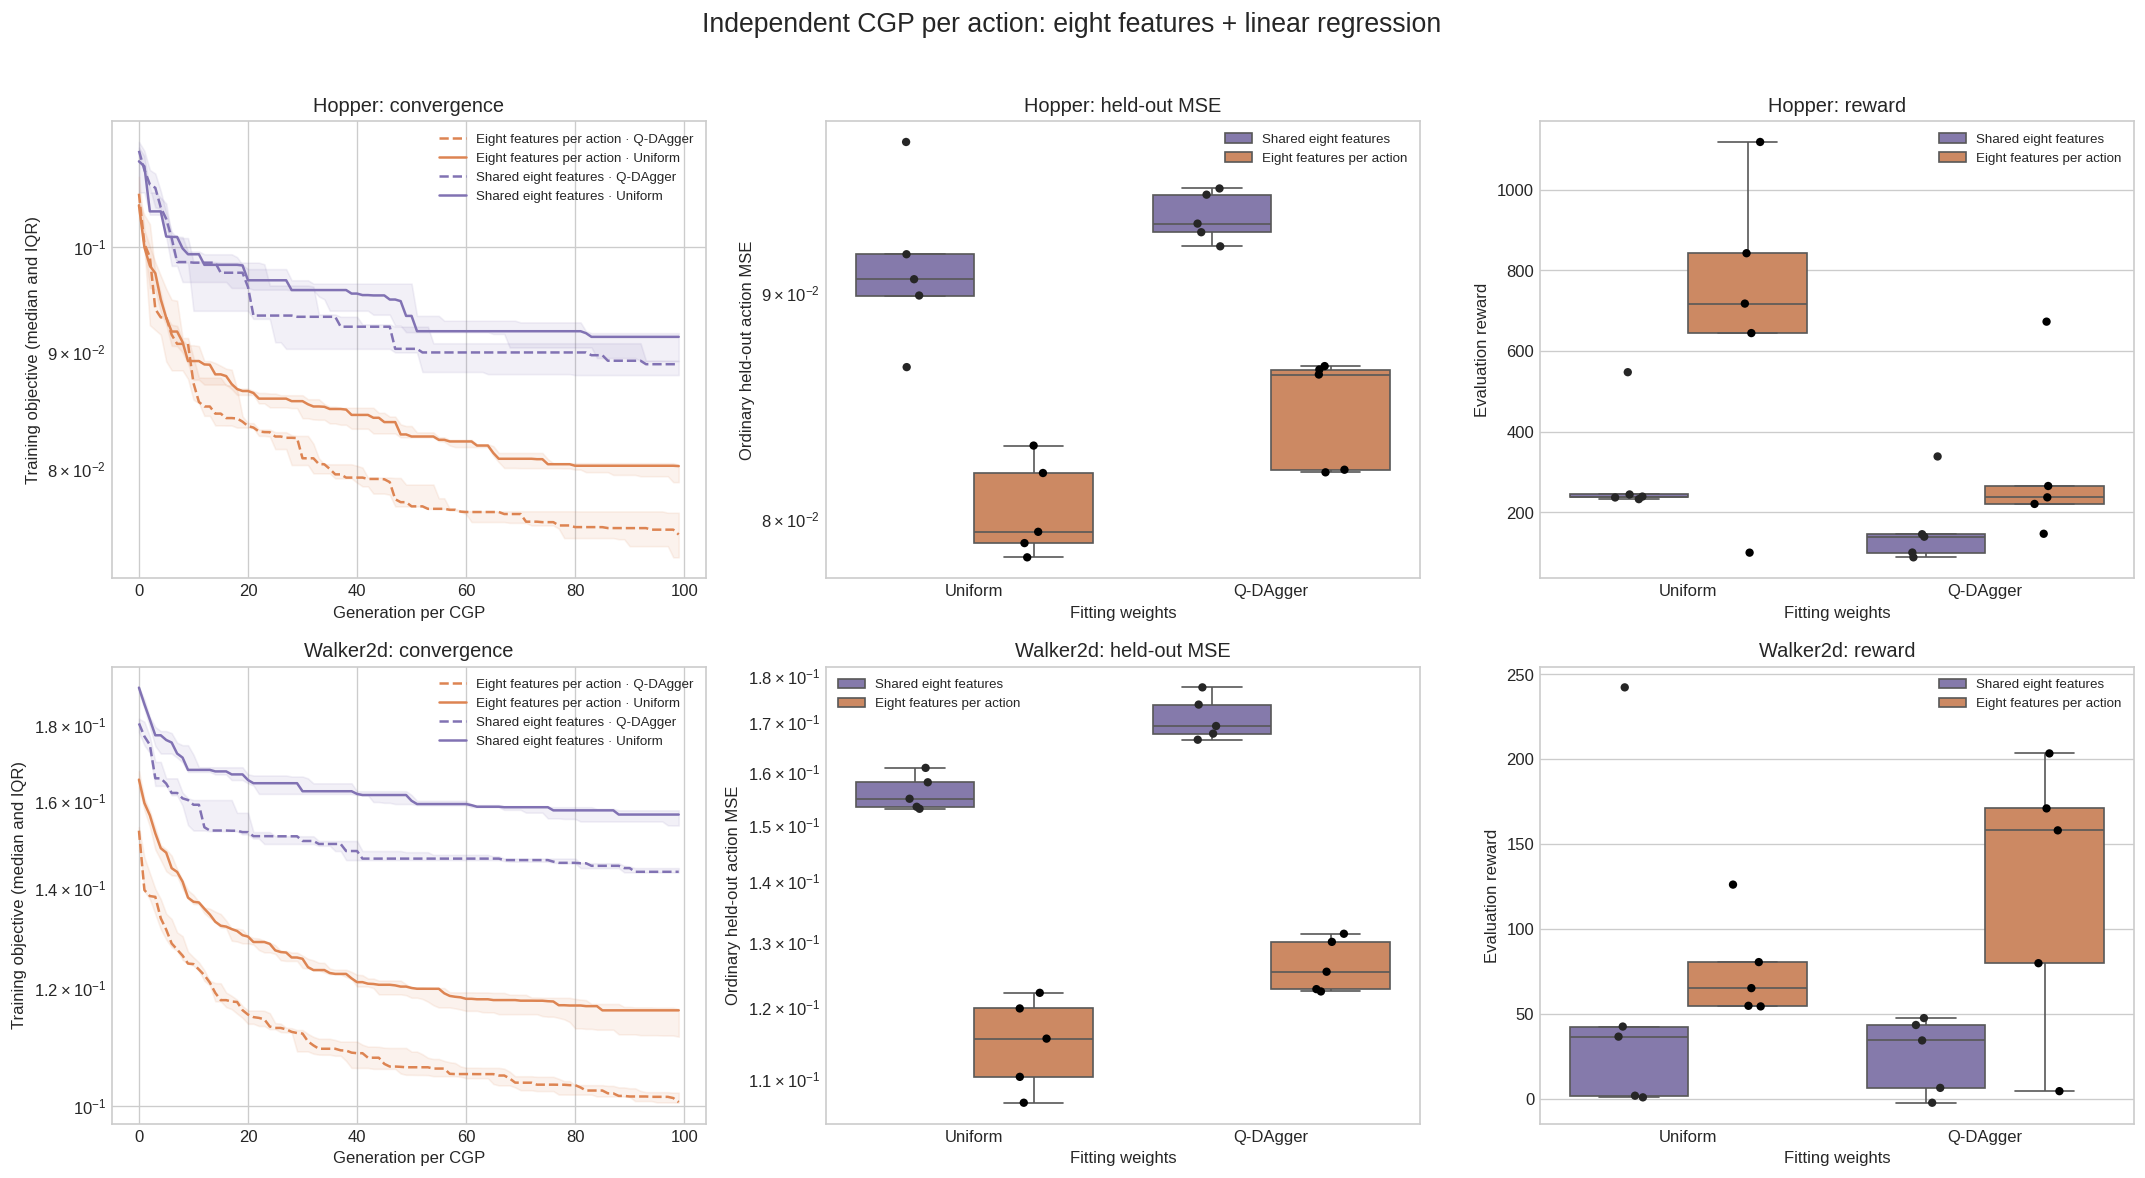

In [10]:

plt.style.use('seaborn-v0_8-whitegrid')

ind_root = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / 'distillation_experiments').is_dir())
ind_repertoires = ind_root / 'distillation_experiments/artifacts/repertoires'
ind_env_labels = {'hopper': 'Hopper', 'walker2d': 'Walker2d'}
ind_weight_labels = {'uniform': 'Uniform', 'q_dagger': 'Q-DAgger'}
ind_arch_labels = {'shared': 'Shared eight features', 'independent': 'Eight features per action'}
ind_colors = {'Shared eight features': '#8172B3', 'Eight features per action': '#DD8452'}
ind_corrections = json.loads((ind_repertoires / 'initial_feature_comparison_evaluation/corrections.json').read_text())
ind_rows, ind_histories = [], []
for env in ind_env_labels:
    for weighting in ind_weight_labels:
        for architecture in ind_arch_labels:
            if architecture == 'shared':
                directory = ind_repertoires / f'cgp_feature_{env}' / f'ann_initial_{weighting}_k8_5seeds'
            else:
                directory = ind_repertoires / f'cgp_action_feature_{env}' / f'ann_independent_{weighting}_k8_5seeds'
            records = json.loads((directory / 'aggregate_summary.json').read_text())['variants']
            assert len(records) == 5
            for record in records:
                reward = record['reward']
                if architecture == 'shared':
                    for correction in ind_corrections:
                        if (correction['environment_key'] == env and correction['model'].startswith('CGP')
                            and correction['weighting'] == ind_weight_labels[weighting] and correction['seed'] == record['seed']):
                            reward = correction['reward']
                ind_rows.append(dict(environment=ind_env_labels[env], architecture=ind_arch_labels[architecture],
                    weighting=ind_weight_labels[weighting], seed=record['seed'], reward=reward,
                    train_mse=record['train_mse'], test_mse=record['validation_mse'],
                    weighted_test_mse=record['validation_weighted_mse'],
                    fit_seconds=record['fit_seconds'], source=str(directory.relative_to(ind_root))))
                history = pd.read_csv(directory / f"seed_{record['seed']}" / 'search_history.csv')
                history['environment'] = ind_env_labels[env]
                history['architecture'] = ind_arch_labels[architecture]
                history['weighting'] = ind_weight_labels[weighting]
                history['seed'] = record['seed']
                ind_histories.append(history)
ind_results = pd.DataFrame(ind_rows)
assert len(ind_results) == 40
ind_history = pd.concat(ind_histories, ignore_index=True)
ind_summary = ind_results.groupby(['environment', 'weighting', 'architecture']).agg(
    seeds=('seed', 'nunique'), finite_rewards=('reward', lambda x: np.isfinite(x).sum()),
    mean_reward=('reward', 'mean'), std_reward=('reward', 'std'),
    mean_test_mse=('test_mse', 'mean'), mean_weighted_test_mse=('weighted_test_mse', 'mean'),
    mean_fit_seconds=('fit_seconds', 'mean'),
).reset_index()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row_index, env_label in enumerate(ind_env_labels.values()):
    frame = ind_results[ind_results.environment.eq(env_label)]
    history = ind_history[ind_history.environment.eq(env_label)]
    for (architecture, weighting), group in history.groupby(['architecture', 'weighting']):
        quantiles = group.groupby('generation').best_loss.quantile([.25, .5, .75]).unstack()
        ax = axes[row_index, 0]
        ax.plot(quantiles.index, quantiles[.5], color=ind_colors[architecture],
                linestyle='-' if weighting == 'Uniform' else '--', label=f'{architecture} · {weighting}')
        ax.fill_between(quantiles.index, quantiles[.25], quantiles[.75], color=ind_colors[architecture], alpha=.1)
    axes[row_index, 0].set(title=f'{env_label}: convergence', xlabel='Generation per CGP',
                          ylabel='Training objective (median and IQR)', yscale='log')
    axes[row_index, 0].legend(fontsize=8)
    for column, metric, label in [(1, 'test_mse', 'Ordinary held-out action MSE'), (2, 'reward', 'Evaluation reward')]:
        ax = axes[row_index, column]
        sns.boxplot(data=frame, x='weighting', y=metric, hue='architecture',
            order=list(ind_weight_labels.values()), hue_order=list(ind_arch_labels.values()),
            palette=ind_colors, showfliers=False, ax=ax)
        sns.stripplot(data=frame, x='weighting', y=metric, hue='architecture',
            order=list(ind_weight_labels.values()), hue_order=list(ind_arch_labels.values()),
            dodge=True, color='black', size=5, legend=False, ax=ax)
        ax.set(title=f'{env_label}: {"held-out MSE" if column == 1 else "reward"}', xlabel='Fitting weights', ylabel=label)
        if column == 1:
            ax.set_yscale('log')
        ax.legend(fontsize=8)
fig.suptitle('Independent CGP per action: eight features + linear regression', fontsize=16)
fig.tight_layout(rect=(0, 0, 1, .96))
plt.show()


# Supplementary: feature-count sensitivity across four environments

k=1,2,4,8,16,32, five seeds per setting. Metric rows and environment columns; color identifies weighting, line/marker style identifies shared versus per-action CGP. Bands show IQR; MSE is unweighted.


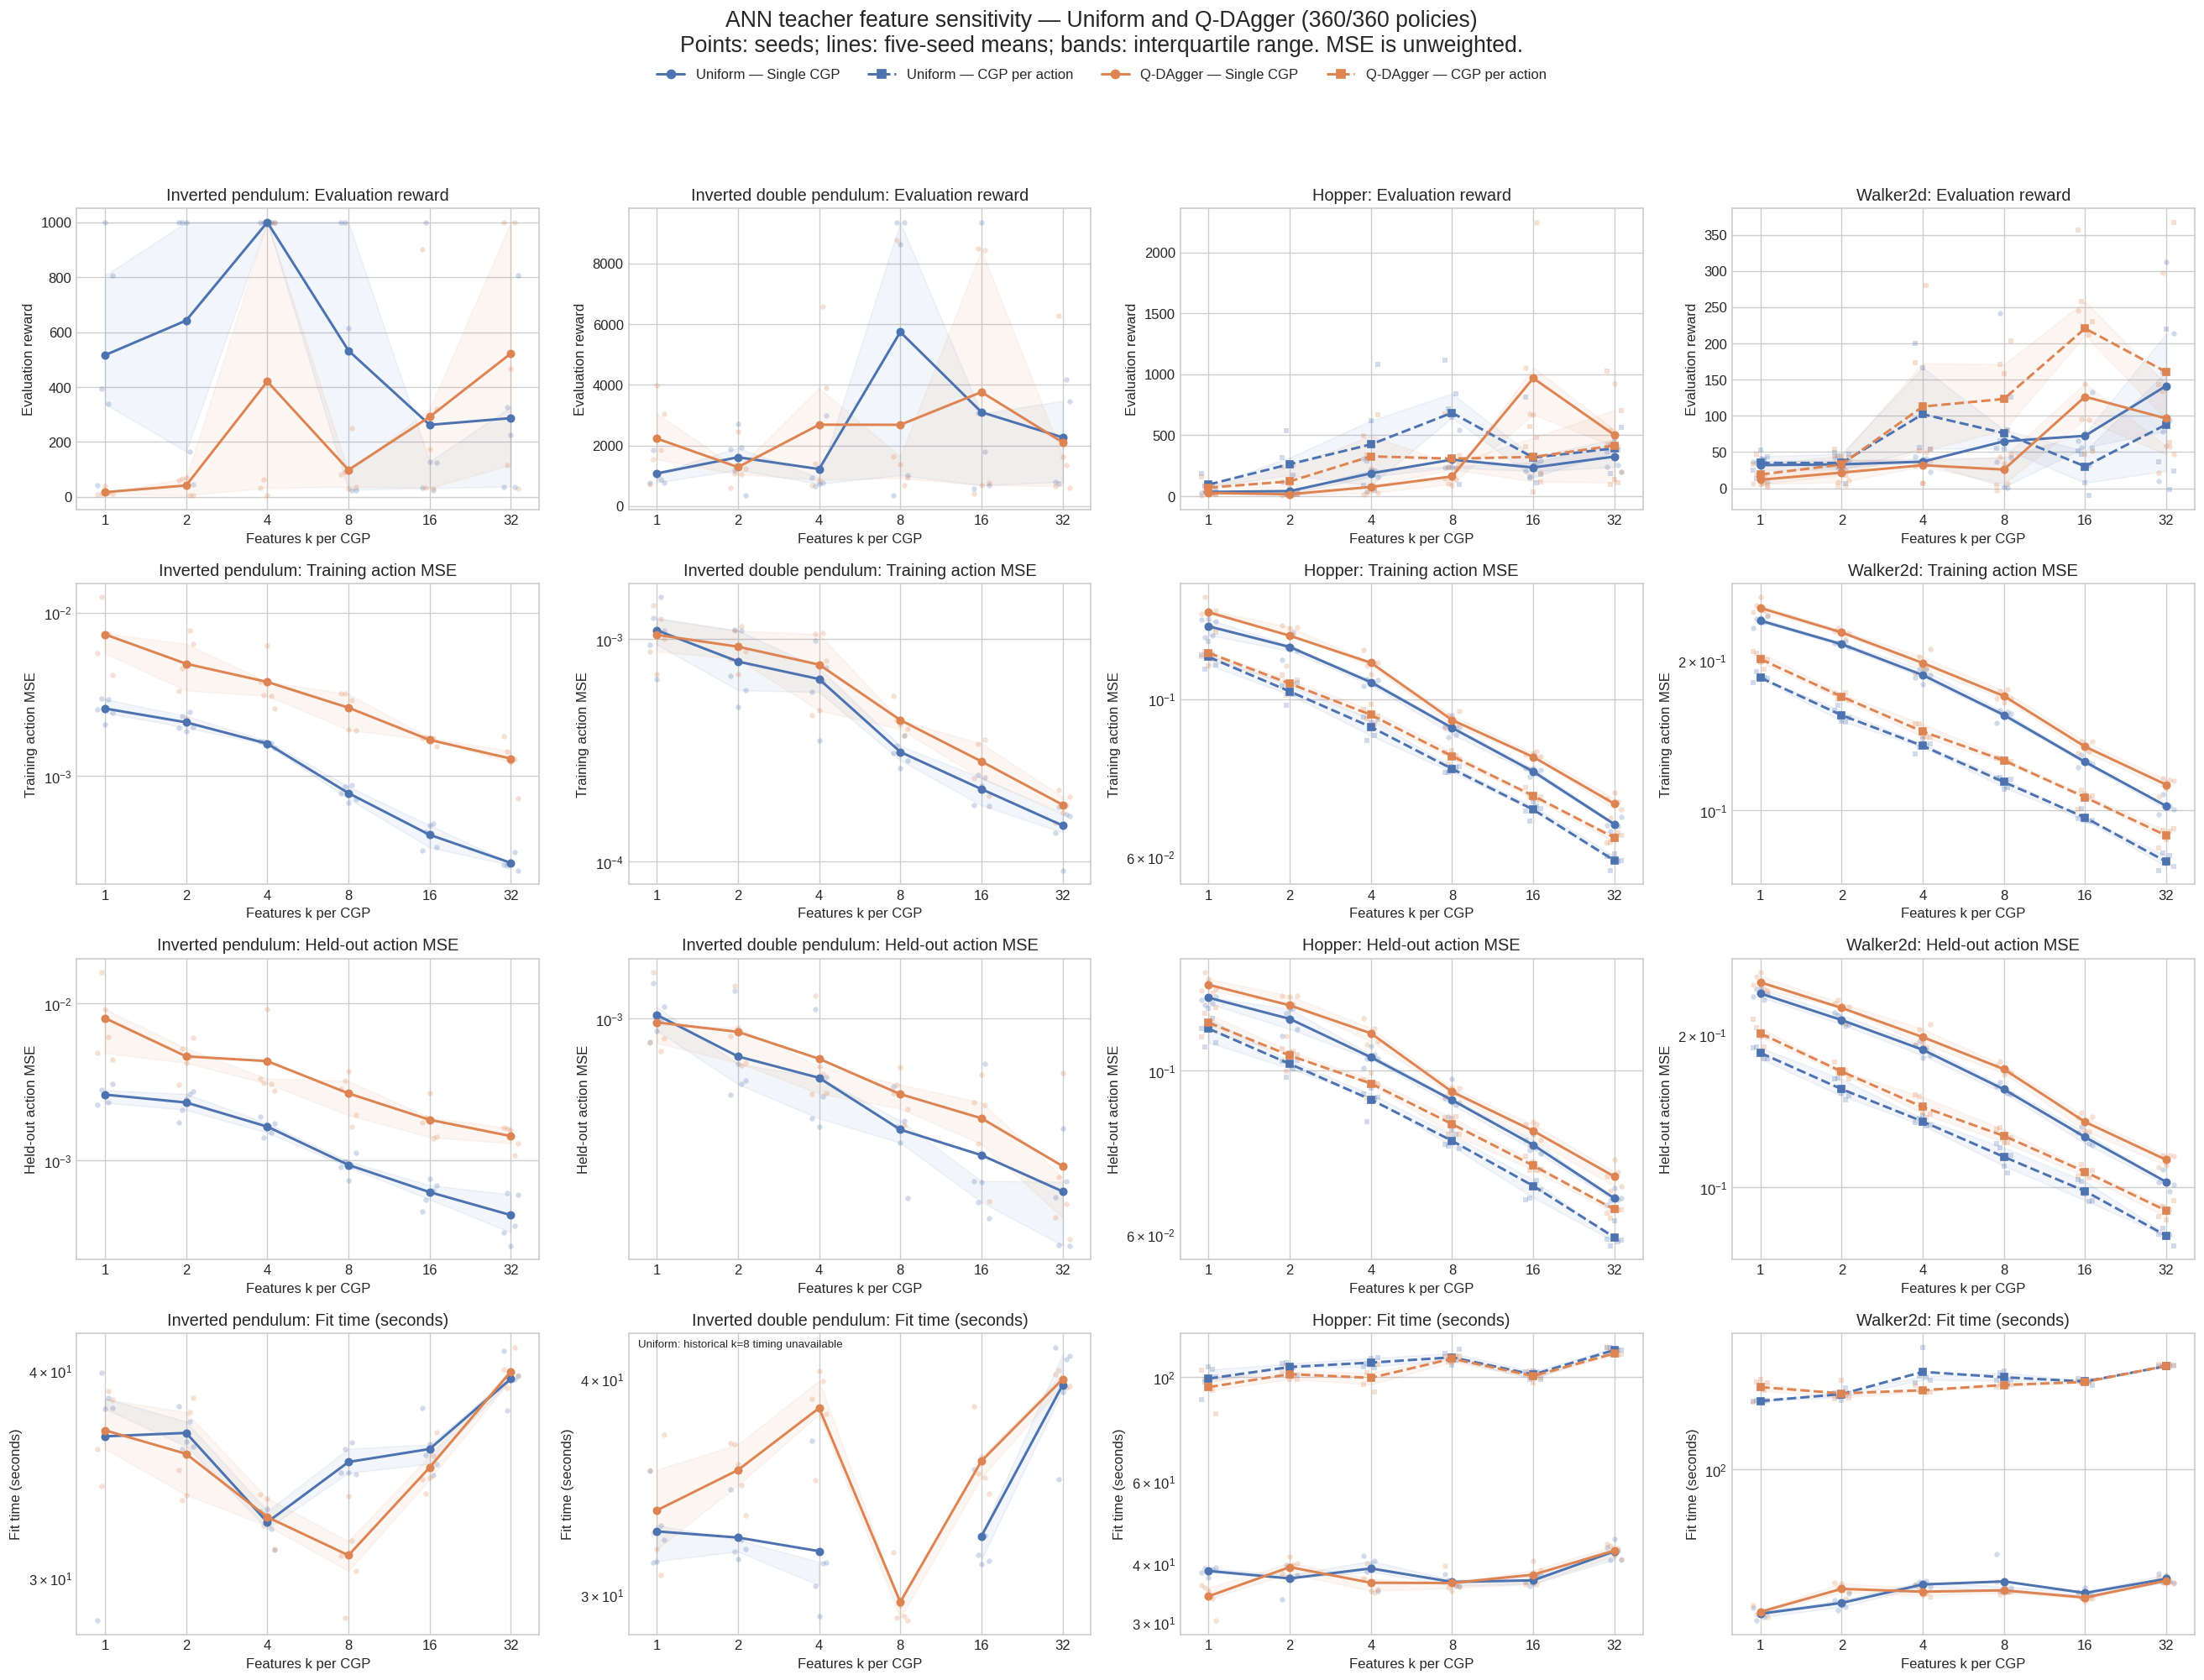

In [11]:
sweep_root = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / 'distillation_experiments').is_dir())
if str(sweep_root) not in sys.path:
    sys.path.insert(0, str(sweep_root))
ann_sweep_results, ann_sweep_manifest = collect_results(sweep_root)
ann_sweep_summary = summarize(ann_sweep_results)
for _, figure in plot_results(ann_sweep_results):
    display(figure)
    plt.close(figure)

